In [1]:
import pandas as pd
import numpy as np
import shap
import warnings
import joblib
import sys
import psutil
import GPUtil
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, GroupKFold, cross_val_predict, ParameterGrid
from collections import defaultdict
from time import time
from datetime import timedelta
from importlib.metadata import version

# printout of python version
print("="*50, "Python Version", "="*50)
print(f"python version: {sys.version}")
print(f"xgboost:        {version('xgboost')}")
print(f"shap:           {version('shap')}")

# printout of hardware
print("="*50, "Hardware", "="*50)
gpus = GPUtil.getGPUs()
for gpu in gpus:
    print(f"GPU: {gpu.name}")
print(f"CPU cores: {psutil.cpu_count(logical=False)}")
print(f"RAM: {psutil.virtual_memory().total / 1024 / 1024 / 1024 :.2f} GB")

warnings.filterwarnings('ignore')

================================================== Python Version ==================================================
python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
xgboost:        2.1.1
shap:           0.46.0
================================================== Hardware ==================================================
GPU: NVIDIA GeForce RTX 4090
CPU cores: 16
RAM: 63.82 GB


# read data function

In [2]:
def read_abcd(path, cols, na_values):
    
    df = pd.read_csv(path, sep='\t', index_col='subjectkey', na_values=na_values)
    df = df.drop(df.index[0])
    
    for col in cols:
        df[col] = pd.to_numeric(df[col])
        df = df[cols]

    df = df.reset_index()
    df = df.sort_values(['subjectkey', 'interview_age'])
    df = df.drop_duplicates(subset=['subjectkey'], keep='first')
    df = df.drop(columns=['interview_age'])
    df = df.set_index('subjectkey')
    
    df_show = abcd_ysu02.join(df)
    df_show = df_show.drop(columns=[
        'isip_1d_2',
        'isip_5_2',
        'isip_1b_yn'
    ])
     
    for col in df_show.columns:
        print('{:<30}    n = {:<10}    mean = {:<10.4f}    sum = {:<10.1f}'.\
              format(col,  df_show[col].notnull().sum(), df_show[col].mean(), df_show[col].sum()))    
    print('\nsubjects:{:>10}\nfeatures:{:>10}'.format(df_show.shape[0], df_show.shape[1]))
    
    return df

# y-target variable

In [3]:
file_abcd_ysu02 = r'D:\gregn\data\ABCD\abcd3\abcd_ysu02.txt'
abcd_ysu02 = pd.read_csv(file_abcd_ysu02, sep='\t', index_col='subjectkey')
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02.index[0])
cols = [
    'interview_age',
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn'
]

for col in cols:
    abcd_ysu02[col] = pd.to_numeric(abcd_ysu02[col])
    abcd_ysu02 = abcd_ysu02[cols]
    
abcd_ysu02 = abcd_ysu02.reset_index()
abcd_ysu02 = abcd_ysu02.sort_values(['subjectkey', 'interview_age'])
abcd_ysu02 = abcd_ysu02.drop_duplicates(subset=['subjectkey'], keep='first')
abcd_ysu02 = abcd_ysu02.drop(columns=['interview_age'])
abcd_ysu02 = abcd_ysu02.set_index('subjectkey')
    
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_5_2 == 3].index) # drop accidental 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_5_2 == 2].index) # drop furtive 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_1b_yn == 0].index) # drop religious 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_1d_2 > 10].index) # drop older than 10

abcd_ysu02['isip_1d_2'] = abcd_ysu02['isip_1d_2'].fillna(0)

y = abcd_ysu02['isip_1d_2'].values
y = np.where(y>0, 1, y)

unique, counts = np.unique(y, return_counts=True)

print('number of subjects: {:>10}\n\n[0] never sipped: {:>12}\n[1] sipped by age 10:{:>9}'.\
      format(len(y), counts[0], counts[1]))

number of subjects:      10707

[0] never sipped:         9209
[1] sipped by age 10:     1498


# acspsw03

In [4]:
path = r'D:\gregn\data\ABCD\abcd3\acspsw03.txt'

cols = [
    'interview_age',
    'rel_family_id',
]

na_values = [None]
acspsw03 = read_abcd(path, cols, na_values)

rel_family_id                     n = 10707         mean = 5921.1416     sum = 63397663.0

subjects:     10707
features:         1


# midaparc03

In [5]:
path = r'D:\gregn\data\ABCD\abcd3\midaparc03.txt'

cols = [
    'interview_age',
    
    # thalamus-proper
    'tfmri_ma_acdn_b_scs_tplh',
    'tfmri_ma_acdn_b_scs_tprh',
    'tfmri_ma_acvn_b_scs_tplh',
    'tfmri_ma_acvn_b_scs_tprh',
    'tfmri_ma_rpvnfb_b_scs_tplh',
    'tfmri_ma_rpvnfb_b_scs_tprh',
    'tfmri_ma_lpvnfb_b_scs_tplh',
    'tfmri_ma_lpvnfb_b_scs_tprh',
    'tfmri_ma_alrvn_b_scs_tplh',
    'tfmri_ma_alrvn_b_scs_tprh',
    'tfmri_ma_asrvn_b_scs_tplh',
    'tfmri_ma_asrvn_b_scs_tprh',
    'tfmri_ma_alvcr_b_scs_tplh',
    'tfmri_ma_alvcr_b_scs_tprh',
    'tfmri_ma_aclvn_b_scs_tplh',
    'tfmri_ma_aclvn_b_scs_tprh',
    'tfmri_ma_acmvn_b_scs_tplh',
    'tfmri_ma_acmvn_b_scs_tprh',
    'tfmri_ma_acgml_b_scs_tplh',
    'tfmri_ma_acgml_b_scs_tprh',
    
    # caudate
    'tfmri_ma_acdn_b_scs_cdlh',
    'tfmri_ma_acdn_b_scs_cdrh',
    'tfmri_ma_acvn_b_scs_cdlh',
    'tfmri_ma_acvn_b_scs_cdrh',
    'tfmri_ma_rpvnfb_b_scs_cdlh',
    'tfmri_ma_rpvnfb_b_scs_cdrh',
    'tfmri_ma_lpvnfb_b_scs_cdlh',
    'tfmri_ma_lpvnfb_b_scs_cdrh',
    'tfmri_ma_alrvn_b_scs_cdlh',
    'tfmri_ma_alrvn_b_scs_cdrh',
    'tfmri_ma_asrvn_b_scs_cdlh',
    'tfmri_ma_asrvn_b_scs_cdrh',
    'tfmri_ma_alvcr_b_scs_cdlh',
    'tfmri_ma_alvcr_b_scs_cdrh',
    'tfmri_ma_aclvn_b_scs_cdlh',
    'tfmri_ma_aclvn_b_scs_cdrh',
    'tfmri_ma_acmvn_b_scs_cdlh',
    'tfmri_ma_acmvn_b_scs_cdrh',
    'tfmri_ma_acgml_b_scs_cdlh',
    'tfmri_ma_acgml_b_scs_cdrh',    
    
    # putamen
    'tfmri_ma_acdn_b_scs_ptlh',
    'tfmri_ma_acdn_b_scs_ptrh',
    'tfmri_ma_acvn_b_scs_ptlh',
    'tfmri_ma_acvn_b_scs_ptrh',
    'tfmri_ma_rpvnfb_b_scs_ptlh',
    'tfmri_ma_rpvnfb_b_scs_ptrh',
    'tfmri_ma_lpvnfb_b_scs_ptlh',
    'tfmri_ma_lpvnfb_b_scs_ptrh',
    'tfmri_ma_alrvn_b_scs_ptlh',
    'tfmri_ma_alrvn_b_scs_ptrh',
    'tfmri_ma_asrvn_b_scs_ptlh',
    'tfmri_ma_asrvn_b_scs_ptrh',
    'tfmri_ma_alvcr_b_scs_ptlh',
    'tfmri_ma_alvcr_b_scs_ptrh',
    'tfmri_ma_aclvn_b_scs_ptlh',
    'tfmri_ma_aclvn_b_scs_ptrh',
    'tfmri_ma_acmvn_b_scs_ptlh',
    'tfmri_ma_acmvn_b_scs_ptrh',
    'tfmri_ma_acgml_b_scs_ptlh',
    'tfmri_ma_acgml_b_scs_ptrh',  
    
    # pallidum
    'tfmri_ma_acdn_b_scs_pdlh',
    'tfmri_ma_acdn_b_scs_pdrh',
    'tfmri_ma_acvn_b_scs_pdlh',
    'tfmri_ma_acvn_b_scs_pdrh',
    'tfmri_ma_rpvnfb_b_scs_pdlh',
    'tfmri_ma_rpvnfb_b_scs_pdrh',
    'tfmri_ma_lpvnfb_b_scs_pdlh',
    'tfmri_ma_lpvnfb_b_scs_pdrh',
    'tfmri_ma_alrvn_b_scs_pdlh',
    'tfmri_ma_alrvn_b_scs_pdrh',
    'tfmri_ma_asrvn_b_scs_pdlh',
    'tfmri_ma_asrvn_b_scs_pdrh',
    'tfmri_ma_alvcr_b_scs_pdlh',
    'tfmri_ma_alvcr_b_scs_pdrh',
    'tfmri_ma_aclvn_b_scs_pdlh',
    'tfmri_ma_aclvn_b_scs_pdrh',
    'tfmri_ma_acmvn_b_scs_pdlh',
    'tfmri_ma_acmvn_b_scs_pdrh',
    'tfmri_ma_acgml_b_scs_pdlh',
    'tfmri_ma_acgml_b_scs_pdrh',    
      
    # amygdala
    'tfmri_ma_acdn_b_scs_aylh',
    'tfmri_ma_acdn_b_scs_ayrh',
    'tfmri_ma_acvn_b_scs_aylh',
    'tfmri_ma_acvn_b_scs_ayrh',
    'tfmri_ma_rpvnfb_b_scs_aylh',
    'tfmri_ma_rpvnfb_b_scs_ayrh',
    'tfmri_ma_lpvnfb_b_scs_aylh',
    'tfmri_ma_lpvnfb_b_scs_ayrh',
    'tfmri_ma_alrvn_b_scs_aylh',
    'tfmri_ma_alrvn_b_scs_ayrh',
    'tfmri_ma_asrvn_b_scs_aylh',
    'tfmri_ma_asrvn_b_scs_ayrh',
    'tfmri_ma_alvcr_b_scs_aylh',
    'tfmri_ma_alvcr_b_scs_ayrh',
    'tfmri_ma_aclvn_b_scs_aylh',
    'tfmri_ma_aclvn_b_scs_ayrh',
    'tfmri_ma_acmvn_b_scs_aylh',
    'tfmri_ma_acmvn_b_scs_ayrh',
    'tfmri_ma_acgml_b_scs_aylh',
    'tfmri_ma_acgml_b_scs_ayrh',    
    
     # accumbens-area
    'tfmri_ma_acdn_b_scs_aalh',
    'tfmri_ma_acdn_b_scs_aarh',
    'tfmri_ma_acvn_b_scs_aalh',
    'tfmri_ma_acvn_b_scs_aarh',
    'tfmri_ma_rpvnfb_b_scs_aalh',
    'tfmri_ma_rpvnfb_b_scs_aarh',
    'tfmri_ma_lpvnfb_b_scs_aalh',
    'tfmri_ma_lpvnfb_b_scs_aarh',
    'tfmri_ma_alrvn_b_scs_aalh',
    'tfmri_ma_alrvn_b_scs_aarh',
    'tfmri_ma_asrvn_b_scs_aalh',
    'tfmri_ma_asrvn_b_scs_aarh',
    'tfmri_ma_alvcr_b_scs_aalh',
    'tfmri_ma_alvcr_b_scs_aarh',
    'tfmri_ma_aclvn_b_scs_aalh',
    'tfmri_ma_aclvn_b_scs_aarh',
    'tfmri_ma_acmvn_b_scs_aalh',
    'tfmri_ma_acmvn_b_scs_aarh',
    'tfmri_ma_acgml_b_scs_aalh',
    'tfmri_ma_acgml_b_scs_aarh',     
    
     # brain-stem
    'tfmri_ma_acdn_b_scs_bs',
    'tfmri_ma_acvn_b_scs_bs',
    'tfmri_ma_rpvnfb_b_scs_bs',
    'tfmri_ma_lpvnfb_b_scs_bs',
    'tfmri_ma_alrvn_b_scs_bs',
    'tfmri_ma_asrvn_b_scs_bs',
    'tfmri_ma_alvcr_b_scs_bs',
    'tfmri_ma_aclvn_b_scs_bs',
    'tfmri_ma_acmvn_b_scs_bs',
    'tfmri_ma_acgml_b_scs_bs',   
    
]

na_values = [None]
midaparc03 = read_abcd(path, cols, na_values)

tfmri_ma_acdn_b_scs_tplh          n = 9427          mean = 0.0188        sum = 177.4     
tfmri_ma_acdn_b_scs_tprh          n = 9427          mean = 0.0287        sum = 270.3     
tfmri_ma_acvn_b_scs_tplh          n = 9426          mean = 0.0135        sum = 127.3     
tfmri_ma_acvn_b_scs_tprh          n = 9426          mean = 0.0188        sum = 177.6     
tfmri_ma_rpvnfb_b_scs_tplh        n = 9426          mean = -0.0191       sum = -180.0    
tfmri_ma_rpvnfb_b_scs_tprh        n = 9426          mean = -0.0210       sum = -197.8    
tfmri_ma_lpvnfb_b_scs_tplh        n = 9425          mean = -0.0133       sum = -125.7    
tfmri_ma_lpvnfb_b_scs_tprh        n = 9425          mean = -0.0186       sum = -175.7    
tfmri_ma_alrvn_b_scs_tplh         n = 9426          mean = 0.0360        sum = 339.6     
tfmri_ma_alrvn_b_scs_tprh         n = 9426          mean = 0.0491        sum = 462.5     
tfmri_ma_asrvn_b_scs_tplh         n = 9426          mean = 0.0019        sum = 17.8      
tfmri_ma_a

# midaparcp203

In [6]:
path = r'D:\gregn\data\ABCD\abcd3\midaparcp203.txt'

cols = [
    'interview_age',
    
    # caudalanteriorcingulate
    'tfmri_ma_arvn_b_cds_clatcgelh',
    'tfmri_ma_arvn_b_cds_clatcgerh',
    'tfmri_ma_acvn_b_cds_clatcgelh',
    'tfmri_ma_acvn_b_cds_clatcgerh',
    'tfmri_ma_rpvnfb_b_cds_clcgelh',
    'tfmri_ma_rpvnfb_b_cds_clagerh',
    'tfmri_ma_lvnfb_b_cds_clatcgelh',
    'tfmri_ma_lvnfb_b_cds_clatcgerh',
    'tfmri_ma_alrvn_b_cds_clatcgelh',
    'tfmri_ma_alrvn_b_cds_clatcgerh',
    'tfmri_ma_asrvn_b_cds_clatcgelh',
    'tfmri_ma_asrvn_b_cds_clatcgerh',
    'tfmri_ma_alvsr_b_cds_clatcgelh',
    'tfmri_ma_alvsr_b_cds_clatcgerh',
    'tfmri_ma_allvn_b_cds_clatcgelh',
    'tfmri_ma_allvn_b_cds_clatcgerh',
    'tfmri_ma_asvn_b_cds_clatcgelh',
    'tfmri_ma_asvn_b_cds_clatcgerh',
    'tfmri_ma_alvsl_b_cds_clatcgelh',
    'tfmri_ma_alvsl_b_cds_clatcgerh',
    
    # lateraloccipital
    'tfmri_ma_arvn_b_cds_loclh',
    'tfmri_ma_arvn_b_cds_locrh',
    'tfmri_ma_acvn_b_cds_loclh',
    'tfmri_ma_acvn_b_cds_locrh',
    'tfmri_ma_rpvnfb_b_cds_loclh',
    'tfmri_ma_rpvnfb_b_cds_locrh',
    'tfmri_ma_lvnfb_b_cds_loclh',
    'tfmri_ma_lvnfb_b_cds_locrh',
    'tfmri_ma_alrvn_b_cds_loclh',
    'tfmri_ma_alrvn_b_cds_locrh',
    'tfmri_ma_asrvn_b_cds_loclh',
    'tfmri_ma_asrvn_b_cds_locrh',
    'tfmri_ma_alvsr_b_cds_loclh',
    'tfmri_ma_alvsr_b_cds_locrh',
    'tfmri_ma_allvn_b_cds_loclh',
    'tfmri_ma_allvn_b_cds_locrh',
    'tfmri_ma_asvn_b_cds_loclh',
    'tfmri_ma_asvn_b_cds_locrh',
    'tfmri_ma_alvsl_b_cds_loclh',
    'tfmri_ma_alvsl_b_cds_locrh',  
    
    # lateralorbitofrontal
    'tfmri_ma_arvn_b_cds_lobofrlh',
    'tfmri_ma_arvn_b_cds_lobofrrh',
    'tfmri_ma_acvn_b_cds_lobofrlh',
    'tfmri_ma_acvn_b_cds_lobofrrh',
    'tfmri_ma_rpvnfb_b_cds_lobofrlh',
    'tfmri_ma_rpvnfb_b_cds_lobofrrh',
    'tfmri_ma_lvnfb_b_cds_lobofrlh',
    'tfmri_ma_lvnfb_b_cds_lobofrrh',
    'tfmri_ma_alrvn_b_cds_lobofrlh',
    'tfmri_ma_alrvn_b_cds_lobofrrh',
    'tfmri_ma_asrvn_b_cds_lobofrlh',
    'tfmri_ma_asrvn_b_cds_lobofrrh',
    'tfmri_ma_alvsr_b_cds_lobofrlh',
    'tfmri_ma_alvsr_b_cds_lobofrrh',
    'tfmri_ma_allvn_b_cds_lobofrlh',
    'tfmri_ma_allvn_b_cds_lobofrrh',
    'tfmri_ma_asvn_b_cds_lobofrlh',
    'tfmri_ma_asvn_b_cds_lobofrrh',
    'tfmri_ma_alvsl_b_cds_lobofrlh',
    'tfmri_ma_alvsl_b_cds_lobofrrh',   
    
    # medialorbitofrontal
    'tfmri_ma_arvn_b_cds_mobofrlh',
    'tfmri_ma_arvn_b_cds_mobofrrh',
    'tfmri_ma_acvn_b_cds_mobofrlh',
    'tfmri_ma_acvn_b_cds_mobofrrh',
    'tfmri_ma_rpvnfb_b_cds_mobofrlh',
    'tfmri_ma_rpvnfb_b_cds_mobofrrh',
    'tfmri_ma_lvnfb_b_cds_mobofrlh',
    'tfmri_ma_lvnfb_b_cds_mobofrrh',
    'tfmri_ma_alrvn_b_cds_mobofrlh',
    'tfmri_ma_alrvn_b_cds_mobofrrh',
    'tfmri_ma_asrvn_b_cds_mobofrlh',
    'tfmri_ma_asrvn_b_cds_mobofrrh',
    'tfmri_ma_alvsr_b_cds_mobofrlh',
    'tfmri_ma_alvsr_b_cds_mobofrrh',
    'tfmri_ma_allvn_b_cds_mobofrlh',
    'tfmri_ma_allvn_b_cds_mobofrrh',
    'tfmri_ma_asvn_b_cds_mobofrlh',
    'tfmri_ma_asvn_b_cds_mobofrrh',
    'tfmri_ma_alvsl_b_cds_mobofrlh',
    'tfmri_ma_alvsl_b_cds_mobofrrh',   
    
    # parsopercularis
    'tfmri_ma_arvn_b_cds_ppclh',
    'tfmri_ma_arvn_b_cds_ppcrh',
    'tfmri_ma_acvn_b_cds_ppclh',
    'tfmri_ma_acvn_b_cds_ppcrh',
    'tfmri_ma_rpvnfb_b_cds_ppclh',
    'tfmri_ma_rpvnfb_b_cds_ppcrh',
    'tfmri_ma_lvnfb_b_cds_ppclh',
    'tfmri_ma_lvnfb_b_cds_ppcrh',
    'tfmri_ma_alrvn_b_cds_ppclh',
    'tfmri_ma_alrvn_b_cds_ppcrh',
    'tfmri_ma_asrvn_b_cds_ppclh',
    'tfmri_ma_asrvn_b_cds_ppcrh',
    'tfmri_ma_alvsr_b_cds_ppclh',
    'tfmri_ma_alvsr_b_cds_ppcrh',
    'tfmri_ma_allvn_b_cds_ppclh',
    'tfmri_ma_allvn_b_cds_ppcrh',
    'tfmri_ma_asvn_b_cds_ppclh',
    'tfmri_ma_asvn_b_cds_ppcrh',
    'tfmri_ma_alvsl_b_cds_ppclh',
    'tfmri_ma_alvsl_b_cds_ppcrh',   
    
    # posteriorcingulate
    'tfmri_ma_arvn_b_cds_pocgelh',
    'tfmri_ma_arvn_b_cds_pocgerh',
    'tfmri_ma_acvn_b_cds_pocgelh',
    'tfmri_ma_acvn_b_cds_pocgerh',
    'tfmri_ma_rpvnfb_b_cds_pocgelh',
    'tfmri_ma_rpvnfb_b_cds_pocgerh',
    'tfmri_ma_lvnfb_b_cds_pocgelh',
    'tfmri_ma_lvnfb_b_cds_pocgerh',
    'tfmri_ma_alrvn_b_cds_pocgelh',
    'tfmri_ma_alrvn_b_cds_pocgerh',
    'tfmri_ma_asrvn_b_cds_pocgelh',
    'tfmri_ma_asrvn_b_cds_pocgerh',
    'tfmri_ma_alvsr_b_cds_pocgelh',
    'tfmri_ma_alvsr_b_cds_pocgerh',
    'tfmri_ma_allvn_b_cds_pocgelh',
    'tfmri_ma_allvn_b_cds_pocgerh',
    'tfmri_ma_asvn_b_cds_pocgelh',
    'tfmri_ma_asvn_b_cds_pocgerh',
    'tfmri_ma_alvsl_b_cds_pocgelh',
    'tfmri_ma_alvsl_b_cds_pocgerh',   
    
    # precentral
    'tfmri_ma_arvn_b_cds_preclh',
    'tfmri_ma_arvn_b_cds_precrh',
    'tfmri_ma_acvn_b_cds_preclh',
    'tfmri_ma_acvn_b_cds_precrh',
    'tfmri_ma_rpvnfb_b_cds_preclh',
    'tfmri_ma_rpvnfb_b_cds_precrh',
    'tfmri_ma_lvnfb_b_cds_preclh',
    'tfmri_ma_lvnfb_b_cds_precrh',
    'tfmri_ma_alrvn_b_cds_preclh',
    'tfmri_ma_alrvn_b_cds_precrh',
    'tfmri_ma_asrvn_b_cds_preclh',
    'tfmri_ma_asrvn_b_cds_precrh',
    'tfmri_ma_alvsr_b_cds_preclh',
    'tfmri_ma_alvsr_b_cds_precrh',
    'tfmri_ma_allvn_b_cds_preclh',
    'tfmri_ma_allvn_b_cds_precrh',
    'tfmri_ma_asvn_b_cds_preclh',
    'tfmri_ma_asvn_b_cds_precrh',
    'tfmri_ma_alvsl_b_cds_preclh',
    'tfmri_ma_alvsl_b_cds_precrh',    
    
    # precuneus
    'tfmri_ma_arvn_b_cds_pulh',
    'tfmri_ma_arvn_b_cds_purh',
    'tfmri_ma_acvn_b_cds_pulh',
    'tfmri_ma_acvn_b_cds_purh',
    'tfmri_ma_rpvnfb_b_cds_pulh',
    'tfmri_ma_rpvnfb_b_cds_purh',
    'tfmri_ma_lvnfb_b_cds_pulh',
    'tfmri_ma_lvnfb_b_cds_purh',
    'tfmri_ma_alrvn_b_cds_pulh',
    'tfmri_ma_alrvn_b_cds_purh',
    'tfmri_ma_asrvn_b_cds_pulh',
    'tfmri_ma_asrvn_b_cds_purh',
    'tfmri_ma_alvsr_b_cds_pulh',
    'tfmri_ma_alvsr_b_cds_purh',
    'tfmri_ma_allvn_b_cds_pulh',
    'tfmri_ma_allvn_b_cds_purh',
    'tfmri_ma_asvn_b_cds_pulh',
    'tfmri_ma_asvn_b_cds_purh',
    'tfmri_ma_alvsl_b_cds_pulh',
    'tfmri_ma_alvsl_b_cds_purh',   
    
    # insula
    'tfmri_ma_arvn_b_cds_insulalh',
    'tfmri_ma_arvn_b_cds_insularh',
    'tfmri_ma_acvn_b_cds_insulalh',
    'tfmri_ma_acvn_b_cds_insularh',
    'tfmri_ma_rpvnfb_b_cds_insulalh',
    'tfmri_ma_rpvnfb_b_cds_insularh',
    'tfmri_ma_lvnfb_b_cds_insulalh',
    'tfmri_ma_lvnfb_b_cds_insularh',
    'tfmri_ma_alrvn_b_cds_insulalh',
    'tfmri_ma_alrvn_b_cds_insularh',
    'tfmri_ma_asrvn_b_cds_insulalh',
    'tfmri_ma_asrvn_b_cds_insularh',
    'tfmri_ma_alvsr_b_cds_insulalh',
    'tfmri_ma_alvsr_b_cds_insularh',
    'tfmri_ma_allvn_b_cds_insulalh',
    'tfmri_ma_allvn_b_cds_insularh',
    'tfmri_ma_asvn_b_cds_insulalh',
    'tfmri_ma_asvn_b_cds_insularh',
    'tfmri_ma_alvsl_b_cds_insulalh',
    'tfmri_ma_alvsl_b_cds_insularh',    
    
]

na_values = [None]
midaparcp203 = read_abcd(path, cols, na_values)

tfmri_ma_arvn_b_cds_clatcgelh     n = 9427          mean = 0.0261        sum = 246.0     
tfmri_ma_arvn_b_cds_clatcgerh     n = 9427          mean = 0.0344        sum = 324.0     
tfmri_ma_acvn_b_cds_clatcgelh     n = 9426          mean = 0.0060        sum = 57.0      
tfmri_ma_acvn_b_cds_clatcgerh     n = 9426          mean = 0.0133        sum = 125.2     
tfmri_ma_rpvnfb_b_cds_clcgelh     n = 9426          mean = -0.0129       sum = -121.4    
tfmri_ma_rpvnfb_b_cds_clagerh     n = 9426          mean = -0.0090       sum = -84.6     
tfmri_ma_lvnfb_b_cds_clatcgelh    n = 9425          mean = -0.0290       sum = -273.1    
tfmri_ma_lvnfb_b_cds_clatcgerh    n = 9425          mean = -0.0298       sum = -280.7    
tfmri_ma_alrvn_b_cds_clatcgelh    n = 9426          mean = 0.0473        sum = 445.5     
tfmri_ma_alrvn_b_cds_clatcgerh    n = 9426          mean = 0.0579        sum = 545.6     
tfmri_ma_asrvn_b_cds_clatcgelh    n = 9426          mean = 0.0058        sum = 54.4      
tfmri_ma_a

# mrisst02

In [7]:
path = r'D:\gregn\data\ABCD\abcd3\mrisst02.txt'

cols = [
    'interview_age',
    
    # thalamus-proper
    'tfmri_sacgvf_bscs_tplh',
    'tfmri_sacgvf_bscs_tprh',
    'tfmri_sacsvcg_bscs_tplh',
    'tfmri_sacsvcg_bscs_tprh',
    'tfmri_saisvcg_bscs_tplh',
    'tfmri_saisvcg_bscs_tprh',
    'tfmri_saasvcg_bscs_tplh',
    'tfmri_saasvcg_bscs_tprh',
    'tfmri_sacsvis_bscs_tplh',
    'tfmri_sacsvis_bscs_tprh',
    'tfmri_saigvcg_bscs_tplh',
    'tfmri_saigvcg_bscs_tprh',
    'tfmri_saigvis_bscs_tplh',
    'tfmri_saigvis_bscs_tprh',
    
    # caudate
    'tfmri_sacgvf_bscs_cdelh',
    'tfmri_sacgvf_bscs_cderh',
    'tfmri_sacsvcg_bscs_cdelh',
    'tfmri_sacsvcg_bscs_cderh',
    'tfmri_saisvcg_bscs_cdelh',
    'tfmri_saisvcg_bscs_cderh',
    'tfmri_saasvcg_bscs_cdelh',
    'tfmri_saasvcg_bscs_cderh',
    'tfmri_sacsvis_bscs_cdelh',
    'tfmri_sacsvis_bscs_cderh',
    'tfmri_saigvcg_bscs_cdelh',
    'tfmri_saigvcg_bscs_cderh',
    'tfmri_saigvis_bscs_cdelh',
    'tfmri_saigvis_bscs_cderh',
    
    # caudalmiddlefrontal
    'tfmri_sacgvf_bcdk_cdmdfrlh',
    'tfmri_sacgvf_bcdk_cdmdfrrh',
    'tfmri_sacsvcg_bcdk_cdmdfrlh',
    'tfmri_sacsvcg_bcdk_cdmdfrrh',
    'tfmri_saisvcg_bcdk_cdmdfrlh',
    'tfmri_saisvcg_bcdk_cdmdfrrh',
    'tfmri_saasvcg_bcdk_cdmdfrlh',
    'tfmri_saasvcg_bcdk_cdmdfrrh',
    'tfmri_sacsvis_bcdk_cdmdfrlh',
    'tfmri_sacsvis_bcdk_cdmdfrrh',
    'tfmri_saigvcg_bcdk_cdmdfrlh',
    'tfmri_saigvcg_bcdk_cdmdfrrh',
    'tfmri_saigvis_bcdk_cdmdfrlh',
    'tfmri_saigvis_bcdk_cdmdfrrh',  
    
    # inferiorparietal
    'tfmri_sacgvf_bcdk_ifpalh',
    'tfmri_sacgvf_bcdk_ifparh',
    'tfmri_sacsvcg_bcdk_ifpalh',
    'tfmri_sacsvcg_bcdk_ifparh',
    'tfmri_saisvcg_bcdk_ifpalh',
    'tfmri_saisvcg_bcdk_ifparh',
    'tfmri_saasvcg_bcdk_ifpalh',
    'tfmri_saasvcg_bcdk_ifparh',
    'tfmri_sacsvis_bcdk_ifpalh',
    'tfmri_sacsvis_bcdk_ifparh',
    'tfmri_saigvcg_bcdk_ifpalh',
    'tfmri_saigvcg_bcdk_ifparh',
    'tfmri_saigvis_bcdk_ifpalh',
    'tfmri_saigvis_bcdk_ifparh',   
    
    # parsopercularis
    'tfmri_sacgvf_bcdk_psopelh',
    'tfmri_sacgvf_bcdk_psoperh',
    'tfmri_sacsvcg_bcdk_psopelh',
    'tfmri_sacsvcg_bcdk_psoperh',
    'tfmri_saisvcg_bcdk_psopelh',
    'tfmri_saisvcg_bcdk_psoperh',
    'tfmri_saasvcg_bcdk_psopelh',
    'tfmri_saasvcg_bcdk_psoperh',
    'tfmri_sacsvis_bcdk_psopelh',
    'tfmri_sacsvis_bcdk_psoperh',
    'tfmri_saigvcg_bcdk_psopelh',
    'tfmri_saigvcg_bcdk_psoperh',
    'tfmri_saigvis_bcdk_psopelh',
    'tfmri_saigvis_bcdk_psoperh',    
    
    # parsorbitalis
    'tfmri_sacgvf_bcdk_psobslh',
    'tfmri_sacgvf_bcdk_psobsrh',
    'tfmri_sacsvcg_bcdk_psobslh',
    'tfmri_sacsvcg_bcdk_psobsrh',
    'tfmri_saisvcg_bcdk_psobslh',
    'tfmri_saisvcg_bcdk_psobsrh',
    'tfmri_saasvcg_bcdk_psobslh',
    'tfmri_saasvcg_bcdk_psobsrh',
    'tfmri_sacsvis_bcdk_psobslh',
    'tfmri_sacsvis_bcdk_psobsrh',
    'tfmri_saigvcg_bcdk_psobslh',
    'tfmri_saigvcg_bcdk_psobsrh',
    'tfmri_saigvis_bcdk_psobslh',
    'tfmri_saigvis_bcdk_psobsrh',   
    
    # parstriangularis
    'tfmri_sacgvf_bcdk_pstglh',
    'tfmri_sacgvf_bcdk_pstgrh',
    'tfmri_sacsvcg_bcdk_pstglh',
    'tfmri_sacsvcg_bcdk_pstgrh',
    'tfmri_saisvcg_bcdk_pstglh',
    'tfmri_saisvcg_bcdk_pstgrh',
    'tfmri_saasvcg_bcdk_pstglh',
    'tfmri_saasvcg_bcdk_pstgrh',
    'tfmri_sacsvis_bcdk_pstglh',
    'tfmri_sacsvis_bcdk_pstgrh',
    'tfmri_saigvcg_bcdk_pstglh',
    'tfmri_saigvcg_bcdk_pstgrh',
    'tfmri_saigvis_bcdk_pstglh',
    'tfmri_saigvis_bcdk_pstgrh',  
    
    # postcentral
    'tfmri_sacgvf_bcdk_postcnlh',
    'tfmri_sacgvf_bcdk_postcnrh',
    'tfmri_sacsvcg_bcdk_postcnlh',
    'tfmri_sacsvcg_bcdk_postcnrh',
    'tfmri_saisvcg_bcdk_postcnlh',
    'tfmri_saisvcg_bcdk_postcnrh',
    'tfmri_saasvcg_bcdk_postcnlh',
    'tfmri_saasvcg_bcdk_postcnrh',
    'tfmri_sacsvis_bcdk_postcnlh',
    'tfmri_sacsvis_bcdk_postcnrh',
    'tfmri_saigvcg_bcdk_postcnlh',
    'tfmri_saigvcg_bcdk_postcnrh',
    'tfmri_saigvis_bcdk_postcnlh',
    'tfmri_saigvis_bcdk_postcnrh',     
    
    # precentral
    'tfmri_sacgvf_bcdk_precnlh',
    'tfmri_sacgvf_bcdk_precnrh',
    'tfmri_sacsvcg_bcdk_precnlh',
    'tfmri_sacsvcg_bcdk_precnrh',
    'tfmri_saisvcg_bcdk_precnlh',
    'tfmri_saisvcg_bcdk_precnrh',
    'tfmri_saasvcg_bcdk_precnlh',
    'tfmri_saasvcg_bcdk_precnrh',
    'tfmri_sacsvis_bcdk_precnlh',
    'tfmri_sacsvis_bcdk_precnrh',
    'tfmri_saigvcg_bcdk_precnlh',
    'tfmri_saigvcg_bcdk_precnrh',
    'tfmri_saigvis_bcdk_precnlh',
    'tfmri_saigvis_bcdk_precnrh', 
    
    # precuneus
    'tfmri_sacgvf_bcdk_pculh',
    'tfmri_sacgvf_bcdk_pcurh',
    'tfmri_sacsvcg_bcdk_pculh',
    'tfmri_sacsvcg_bcdk_pcurh',
    'tfmri_saisvcg_bcdk_pculh',
    'tfmri_saisvcg_bcdk_pcurh',
    'tfmri_saasvcg_bcdk_pculh',
    'tfmri_saasvcg_bcdk_pcurh',
    'tfmri_sacsvis_bcdk_pculh',
    'tfmri_sacsvis_bcdk_pcurh',
    'tfmri_saigvcg_bcdk_pculh',
    'tfmri_saigvcg_bcdk_pcurh',
    'tfmri_saigvis_bcdk_pculh',
    'tfmri_saigvis_bcdk_pcurh',  
    
    # rostralanteriorcingulate
    'tfmri_sacgvf_bcdk_racgelh',
    'tfmri_sacgvf_bcdk_racgerh',
    'tfmri_sacsvcg_bcdk_racgelh',
    'tfmri_sacsvcg_bcdk_racgerh',
    'tfmri_saisvcg_bcdk_racgelh',
    'tfmri_saisvcg_bcdk_racgerh',
    'tfmri_saasvcg_bcdk_racgelh',
    'tfmri_saasvcg_bcdk_racgerh',
    'tfmri_sacsvis_bcdk_racgelh',
    'tfmri_sacsvis_bcdk_racgerh',
    'tfmri_saigvcg_bcdk_racgelh',
    'tfmri_saigvcg_bcdk_racgerh',
    'tfmri_saigvis_bcdk_racgelh',
    'tfmri_saigvis_bcdk_racgerh', 
    
    # superiorfrontal
    'tfmri_sacgvf_bcdk_sufrlh',
    'tfmri_sacgvf_bcdk_sufrrh',
    'tfmri_sacsvcg_bcdk_sufrlh',
    'tfmri_sacsvcg_bcdk_sufrrh',
    'tfmri_saisvcg_bcdk_sufrlh',
    'tfmri_saisvcg_bcdk_sufrrh',
    'tfmri_saasvcg_bcdk_sufrlh',
    'tfmri_saasvcg_bcdk_sufrrh',
    'tfmri_sacsvis_bcdk_sufrlh',
    'tfmri_sacsvis_bcdk_sufrrh',
    'tfmri_saigvcg_bcdk_sufrlh',
    'tfmri_saigvcg_bcdk_sufrrh',
    'tfmri_saigvis_bcdk_sufrlh',
    'tfmri_saigvis_bcdk_sufrrh',     
    
    # supramarginal
    'tfmri_sacgvf_bcdk_smlh',
    'tfmri_sacgvf_bcdk_smrh',
    'tfmri_sacsvcg_bcdk_smlh',
    'tfmri_sacsvcg_bcdk_smrh',
    'tfmri_saisvcg_bcdk_smlh',
    'tfmri_saisvcg_bcdk_smrh',
    'tfmri_saasvcg_bcdk_smlh',
    'tfmri_saasvcg_bcdk_smrh',
    'tfmri_sacsvis_bcdk_smlh',
    'tfmri_sacsvis_bcdk_smrh',
    'tfmri_saigvcg_bcdk_smlh',
    'tfmri_saigvcg_bcdk_smrh',
    'tfmri_saigvis_bcdk_smlh',
    'tfmri_saigvis_bcdk_smrh', 
    
    # temporalpole
    'tfmri_sacgvf_bcdk_tppelh',
    'tfmri_sacgvf_bcdk_tpperh',
    'tfmri_sacsvcg_bcdk_tppelh',
    'tfmri_sacsvcg_bcdk_tpperh',
    'tfmri_saisvcg_bcdk_tppelh',
    'tfmri_saisvcg_bcdk_tpperh',
    'tfmri_saasvcg_bcdk_tppelh',
    'tfmri_saasvcg_bcdk_tpperh',
    'tfmri_sacsvis_bcdk_tppelh',
    'tfmri_sacsvis_bcdk_tpperh',
    'tfmri_saigvcg_bcdk_tppelh',
    'tfmri_saigvcg_bcdk_tpperh',
    'tfmri_saigvis_bcdk_tppelh',
    'tfmri_saigvis_bcdk_tpperh',     
    
    # insula
    'tfmri_sacgvf_bcdk_isalh',
    'tfmri_sacgvf_bcdk_isarh',
    'tfmri_sacsvcg_bcdk_isalh',
    'tfmri_sacsvcg_bcdk_isarh',
    'tfmri_saisvcg_bcdk_isalh',
    'tfmri_saisvcg_bcdk_isarh',
    'tfmri_saasvcg_bcdk_isalh',
    'tfmri_saasvcg_bcdk_isarh',
    'tfmri_sacsvis_bcdk_isalh',
    'tfmri_sacsvis_bcdk_isarh',
    'tfmri_saigvcg_bcdk_isalh',
    'tfmri_saigvcg_bcdk_isarh',
    'tfmri_saigvis_bcdk_isalh',
    'tfmri_saigvis_bcdk_isarh',     
]

na_values = [None]
mrisst02 = read_abcd(path, cols, na_values)

tfmri_sacgvf_bscs_tplh            n = 9359          mean = 0.0035        sum = 32.3      
tfmri_sacgvf_bscs_tprh            n = 9359          mean = -0.0047       sum = -44.2     
tfmri_sacsvcg_bscs_tplh           n = 9357          mean = 0.0291        sum = 271.8     
tfmri_sacsvcg_bscs_tprh           n = 9357          mean = 0.0472        sum = 442.1     
tfmri_saisvcg_bscs_tplh           n = 9358          mean = 0.0465        sum = 435.2     
tfmri_saisvcg_bscs_tprh           n = 9358          mean = 0.0518        sum = 484.3     
tfmri_saasvcg_bscs_tplh           n = 9357          mean = 0.0382        sum = 357.8     
tfmri_saasvcg_bscs_tprh           n = 9357          mean = 0.0499        sum = 466.7     
tfmri_sacsvis_bscs_tplh           n = 9356          mean = -0.0173       sum = -161.7    
tfmri_sacsvis_bscs_tprh           n = 9356          mean = -0.0046       sum = -42.8     
tfmri_saigvcg_bscs_tplh           n = 9355          mean = 0.0398        sum = 371.9     
tfmri_saig

# nback_bwroi02

In [8]:
path = r'D:\gregn\data\ABCD\abcd3\nback_bwroi02.txt'

cols = [
    'interview_age',
    
    # hippocampus
    #'tfmri_nback_all_13', # Mean beta weight for nBack 0 back condition in ASEG ROI left-hippocampus
    #'tfmri_nback_all_27', # Mean beta weight for nBack 0 back condition in ASEG ROI right-hippocampus
    #'tfmri_nback_all_43', # Mean beta weight for nBack 2 back condition in ASEG ROI left-hippocampus
    #'tfmri_nback_all_57', # Mean beta weight for nBack 2 back condition in ASEG ROI right-hippocampus
    #'tfmri_nback_all_73', # Mean beta weight for nBack place condition in ASEG ROI left-hippocampus
    #'tfmri_nback_all_87', # Mean beta weight for nBack place condition in ASEG ROI right-hippocampus
    'tfmri_nback_all_103', # Mean beta weight for nBack emotion condition in ASEG ROI left-hippocampus
    'tfmri_nback_all_117', # Mean beta weight for nBack emotion condition in ASEG ROI right-hippocampus
    #'tfmri_nback_all_133', # Mean beta weight for nBack 2 back versus 0 back contrast in ASEG ROI left-hippocampus
    #'tfmri_nback_all_147', # Mean beta weight for nBack 2 back versus 0 back contrast in ASEG ROI right-hippocampus
    'tfmri_nback_all_163', # Mean beta weight for nBack face versus place contrast in ASEG ROI left-hippocampus
    'tfmri_nback_all_177', # Mean beta weight for nBack face versus place contrast in ASEG ROI right-hippocampus
    'tfmri_nback_all_193', # Mean beta weight for nBack emotion versus neutral face contrast in ASEG ROI left-hippocampus
    'tfmri_nback_all_207', # Mean beta weight for nBack emotion versus neutral face contrast in ASEG ROI right-hippocampus
    'tfmri_nback_all_223', # Mean beta weight for nBack negative face versus neutral face contrast in ASEG ROI left-hippocampus
    'tfmri_nback_all_237', # Mean beta weight for nBack negative face versus neutral face contrast in ASEG ROI right-hippocampus
    'tfmri_nback_all_253', # Mean beta weight for nBack positive face versus neutral face contrast in ASEG ROI left-hippocampus	
    'tfmri_nback_all_267', # Mean beta weight for nBack positive face versus neutral face contrast in ASEG ROI right-hippocampus
    
    # amygdala
    #'tfmri_nback_all_14', # Mean beta weight for nBack 0 back condition in ASEG ROI left-amygdala
    #'tfmri_nback_all_28', # Mean beta weight for nBack 0 back condition in ASEG ROI right-amygdala
    #'tfmri_nback_all_44', # Mean beta weight for nBack 2 back condition in ASEG ROI left-amygdala
    #'tfmri_nback_all_58', # Mean beta weight for nBack 2 back condition in ASEG ROI right-amygdala
    #'tfmri_nback_all_74', # Mean beta weight for nBack place condition in ASEG ROI left-amygdala
    #'tfmri_nback_all_88', # Mean beta weight for nBack place condition in ASEG ROI right-amygdala
    'tfmri_nback_all_104', # Mean beta weight for nBack emotion condition in ASEG ROI left-amygdala
    'tfmri_nback_all_118', # Mean beta weight for nBack emotion condition in ASEG ROI right-amygdala
    #'tfmri_nback_all_134', # Mean beta weight for nBack 2 back versus 0 back contrast in ASEG ROI left-amygdala
    #'tfmri_nback_all_148', # Mean beta weight for nBack 2 back versus 0 back contrast in ASEG ROI right-amygdala
    'tfmri_nback_all_164', # Mean beta weight for nBack face versus place contrast in ASEG ROI left-amygdala
    'tfmri_nback_all_178', # Mean beta weight for nBack face versus place contrast in ASEG ROI right-amygdala
    'tfmri_nback_all_194', # Mean beta weight for nBack emotion versus neutral face contrast in ASEG ROI left-amygdala
    'tfmri_nback_all_208', # Mean beta weight for nBack emotion versus neutral face contrast in ASEG ROI right-amygdala
    'tfmri_nback_all_224', # Mean beta weight for nBack negative face versus neutral face contrast in ASEG ROI left-amygdala
    'tfmri_nback_all_238', # Mean beta weight for nBack negative face versus neutral face contrast in ASEG ROI right-amygdala
    'tfmri_nback_all_254', # Mean beta weight for nBack positive face versus neutral face contrast in ASEG ROI left-amygdala
    'tfmri_nback_all_268', # Mean beta weight for nBack positive face versus neutral face contrast in ASEG ROI right-amygdala
    
    # accumbens-area
    #'tfmri_nback_all_16', # Mean beta weight for nBack 0 back condition in ASEG ROI left-accumbens-area
    #'tfmri_nback_all_29', # Mean beta weight for nBack 0 back condition in ASEG ROI right-accumbens-area
    #'tfmri_nback_all_46', # Mean beta weight for nBack 2 back condition in ASEG ROI left-accumbens-area
    #'tfmri_nback_all_59', # Mean beta weight for nBack 2 back condition in ASEG ROI right-accumbens-area
    #'tfmri_nback_all_76', # Mean beta weight for nBack place condition in ASEG ROI left-accumbens-area
    #'tfmri_nback_all_89', # Mean beta weight for nBack place condition in ASEG ROI right-accumbens-area
    'tfmri_nback_all_106', # Mean beta weight for nBack emotion condition in ASEG ROI left-accumbens-area
    'tfmri_nback_all_119', # Mean beta weight for nBack emotion condition in ASEG ROI right-accumbens-area
    #'tfmri_nback_all_136', # Mean beta weight for nBack 2 back versus 0 back contrast in ASEG ROI left-accumbens-area
    #'tfmri_nback_all_149', # Mean beta weight for nBack 2 back versus 0 back contrast in ASEG ROI right-accumbens-area
    'tfmri_nback_all_166', # Mean beta weight for nBack face versus place contrast in ASEG ROI left-accumbens-area
    'tfmri_nback_all_179', # Mean beta weight for nBack face versus place contrast in ASEG ROI right-accumbens-area
    'tfmri_nback_all_196', # Mean beta weight for nBack emotion versus neutral face contrast in ASEG ROI left-accumbens-area
    'tfmri_nback_all_209', # Mean beta weight for nBack emotion versus neutral face contrast in ASEG ROI right-accumbens-area
    'tfmri_nback_all_226', # Mean beta weight for nBack negative face versus neutral face contrast in ASEG ROI left-accumbens-area
    'tfmri_nback_all_239', # Mean beta weight for nBack negative face versus neutral face contrast in ASEG ROI right-accumbens-area
    'tfmri_nback_all_256', # Mean beta weight for nBack positive face versus neutral face contrast in ASEG ROI left-accumbens-area
    'tfmri_nback_all_269', # Mean beta weight for nBack positive face versus neutral face contrast in ASEG ROI right-accumbens-area
    
    # caudalanteriorcingulate
    'tfmri_nback_all_272', # Mean beta weight for nBack 0 back condition in APARC ROI lh-caudalanteriorcingulate
    'tfmri_nback_all_306', # Mean beta weight for nBack 0 back condition in APARC ROI rh-caudalanteriorcingulate
    'tfmri_nback_all_340', # Mean beta weight for nBack 2 back condition in APARC ROI lh-caudalanteriorcingulate
    'tfmri_nback_all_374', # Mean beta weight for nBack 2 back condition in APARC ROI rh-caudalanteriorcingulate
    'tfmri_nback_all_408', # Mean beta weight for nBack place condition in APARC ROI lh-caudalanteriorcingulate
    'tfmri_nback_all_442', # Mean beta weight for nBack place condition in APARC ROI rh-caudalanteriorcingulate
    'tfmri_nback_all_476', # Mean beta weight for nBack emotion condition in APARC ROI lh-caudalanteriorcingulate
    'tfmri_nback_all_510', # Mean beta weight for nBack emotion condition in APARC ROI rh-caudalanteriorcingulate
    'tfmri_nback_all_544', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-caudalanteriorcingulate
    'tfmri_nback_all_578', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-caudalanteriorcingulate
    'tfmri_nback_all_612', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-caudalanteriorcingulate
    'tfmri_nback_all_646', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-caudalanteriorcingulate
    'tfmri_nback_all_680', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-caudalanteriorcingulate
    'tfmri_nback_all_714', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-caudalanteriorcingulate
    'tfmri_nback_all_748', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-caudalanteriorcingulate
    'tfmri_nback_all_782', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-caudalanteriorcingulate
    'tfmri_nback_all_816', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-caudalanteriorcingulate
    'tfmri_nback_all_850', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-caudalanteriorcingulate
    
    # caudalmiddlefrontal
    'tfmri_nback_all_273', # Mean beta weight for nBack 0 back condition in APARC ROI lh-caudalmiddlefrontal
    'tfmri_nback_all_307', # Mean beta weight for nBack 0 back condition in APARC ROI rh-caudalmiddlefrontal
    'tfmri_nback_all_341', # Mean beta weight for nBack 2 back condition in APARC ROI lh-caudalmiddlefrontal
    'tfmri_nback_all_375', # Mean beta weight for nBack 2 back condition in APARC ROI rh-caudalmiddlefrontal
    'tfmri_nback_all_409', # Mean beta weight for nBack place condition in APARC ROI lh-caudalmiddlefrontal
    'tfmri_nback_all_443', # Mean beta weight for nBack place condition in APARC ROI rh-caudalmiddlefrontal
    'tfmri_nback_all_477', # Mean beta weight for nBack emotion condition in APARC ROI lh-caudalmiddlefrontal
    'tfmri_nback_all_511', # Mean beta weight for nBack emotion condition in APARC ROI rh-caudalmiddlefrontal
    'tfmri_nback_all_545', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-caudalmiddlefrontal
    'tfmri_nback_all_579', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-caudalmiddlefrontal
    'tfmri_nback_all_613', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-caudalmiddlefrontal
    'tfmri_nback_all_647', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-caudalmiddlefrontal
    'tfmri_nback_all_681', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-caudalmiddlefrontal
    'tfmri_nback_all_715', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-caudalmiddlefrontal
    'tfmri_nback_all_749', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-caudalmiddlefrontal
    'tfmri_nback_all_783', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-caudalmiddlefrontal
    'tfmri_nback_all_817', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-caudalmiddlefrontal
    'tfmri_nback_all_851', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-caudalmiddlefrontal
    
    # fusiform
    #'tfmri_nback_all_276', # Mean beta weight for nBack 0 back condition in APARC ROI lh-fusiform
    #'tfmri_nback_all_310', # Mean beta weight for nBack 0 back condition in APARC ROI rh-fusiform
    #'tfmri_nback_all_344', # Mean beta weight for nBack 2 back condition in APARC ROI lh-fusiform
    #'tfmri_nback_all_378', # Mean beta weight for nBack 2 back condition in APARC ROI rh-fusiform
    #'tfmri_nback_all_412', # Mean beta weight for nBack place condition in APARC ROI lh-fusiform
    #'tfmri_nback_all_446', # Mean beta weight for nBack place condition in APARC ROI rh-fusiform
    'tfmri_nback_all_480', # Mean beta weight for nBack emotion condition in APARC ROI lh-fusiform
    'tfmri_nback_all_514', # Mean beta weight for nBack emotion condition in APARC ROI rh-fusiform
    #'tfmri_nback_all_548', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-fusiform
    #'tfmri_nback_all_582', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-fusiform
    'tfmri_nback_all_616', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-fusiform
    'tfmri_nback_all_650', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-fusiform
    'tfmri_nback_all_684', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-fusiform
    'tfmri_nback_all_718', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-fusiform
    'tfmri_nback_all_752', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-fusiform	
    'tfmri_nback_all_786', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-fusiform
    'tfmri_nback_all_820', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-fusiform
    'tfmri_nback_all_854', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-fusiform
    
    # inferiorparietal   
    'tfmri_nback_all_277', # Mean beta weight for nBack 0 back condition in APARC ROI lh-inferiorparietal
    'tfmri_nback_all_311', # Mean beta weight for nBack 0 back condition in APARC ROI rh-inferiorparietal
    'tfmri_nback_all_345', # Mean beta weight for nBack 2 back condition in APARC ROI lh-inferiorparietal
    'tfmri_nback_all_379', # Mean beta weight for nBack 2 back condition in APARC ROI rh-inferiorparietal
    'tfmri_nback_all_413', # Mean beta weight for nBack place condition in APARC ROI lh-inferiorparietal
    'tfmri_nback_all_447', # Mean beta weight for nBack place condition in APARC ROI rh-inferiorparietal
    'tfmri_nback_all_481', # Mean beta weight for nBack emotion condition in APARC ROI lh-inferiorparietal
    'tfmri_nback_all_515', # Mean beta weight for nBack emotion condition in APARC ROI rh-inferiorparietal
    'tfmri_nback_all_549', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-inferiorparietal
    'tfmri_nback_all_583', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-inferiorparietal
    'tfmri_nback_all_617', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-inferiorparietal
    'tfmri_nback_all_651', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-inferiorparietal
    'tfmri_nback_all_685', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-inferiorparietal
    'tfmri_nback_all_719', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-inferiorparietal
    'tfmri_nback_all_753', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-inferiorparietal
    'tfmri_nback_all_787', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-inferiorparietal
    'tfmri_nback_all_821', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-inferiorparietal
    'tfmri_nback_all_855', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-inferiorparietal
    
    # medialorbitofrontal
    #'tfmri_nback_all_283', # Mean beta weight for nBack 0 back condition in APARC ROI lh-medialorbitofrontal
    #'tfmri_nback_all_317', # Mean beta weight for nBack 0 back condition in APARC ROI rh-medialorbitofrontal
    #'tfmri_nback_all_351', # Mean beta weight for nBack 2 back condition in APARC ROI lh-medialorbitofrontal
    #'tfmri_nback_all_385', # Mean beta weight for nBack 2 back condition in APARC ROI rh-medialorbitofrontal
    #'tfmri_nback_all_419', # Mean beta weight for nBack place condition in APARC ROI lh-medialorbitofrontal
    #'tfmri_nback_all_453', # Mean beta weight for nBack place condition in APARC ROI rh-medialorbitofrontal
    'tfmri_nback_all_487', # Mean beta weight for nBack emotion condition in APARC ROI lh-medialorbitofrontal
    'tfmri_nback_all_521', # Mean beta weight for nBack emotion condition in APARC ROI rh-medialorbitofrontal
    #'tfmri_nback_all_555', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-medialorbitofrontal
    #'tfmri_nback_all_589', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-medialorbitofrontal
    'tfmri_nback_all_623', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-medialorbitofrontal
    'tfmri_nback_all_657', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-medialorbitofrontal
    'tfmri_nback_all_691', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-medialorbitofrontal
    'tfmri_nback_all_725', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-medialorbitofrontal
    'tfmri_nback_all_759', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-medialorbitofrontal
    'tfmri_nback_all_793', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-medialorbitofrontal
    'tfmri_nback_all_827', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-medialorbitofrontal
    'tfmri_nback_all_861', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-medialorbitofrontal
    
    # parahippocampal
    #'tfmri_nback_all_285', # Mean beta weight for nBack 0 back condition in APARC ROI lh-parahippocampal
    #'tfmri_nback_all_319', # Mean beta weight for nBack 0 back condition in APARC ROI rh-parahippocampal
    #'tfmri_nback_all_353', # Mean beta weight for nBack 2 back condition in APARC ROI lh-parahippocampal
    #'tfmri_nback_all_387', # Mean beta weight for nBack 2 back condition in APARC ROI rh-parahippocampal
    #'tfmri_nback_all_421', # Mean beta weight for nBack place condition in APARC ROI lh-parahippocampal
    #'tfmri_nback_all_455', # Mean beta weight for nBack place condition in APARC ROI rh-parahippocampal
    'tfmri_nback_all_489', # Mean beta weight for nBack emotion condition in APARC ROI lh-parahippocampal
    'tfmri_nback_all_523', # Mean beta weight for nBack emotion condition in APARC ROI rh-parahippocampal
    #'tfmri_nback_all_557', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-parahippocampal
    #'tfmri_nback_all_591', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-parahippocampal
    'tfmri_nback_all_625', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-parahippocampal
    'tfmri_nback_all_659', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-parahippocampal
    'tfmri_nback_all_693', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-parahippocampal
    'tfmri_nback_all_727', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-parahippocampal
    'tfmri_nback_all_761', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-parahippocampal
    'tfmri_nback_all_795', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-parahippocampal
    'tfmri_nback_all_829', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-parahippocampal
    'tfmri_nback_all_863', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-parahippocampal
    
    # parsopercularis
    #'tfmri_nback_all_287', # Mean beta weight for nBack 0 back condition in APARC ROI lh-parsopercularis
    #'tfmri_nback_all_321', # Mean beta weight for nBack 0 back condition in APARC ROI rh-parsopercularis
    #'tfmri_nback_all_355', # Mean beta weight for nBack 2 back condition in APARC ROI lh-parsopercularis
    #'tfmri_nback_all_389', # Mean beta weight for nBack 2 back condition in APARC ROI rh-parsopercularis
    #'tfmri_nback_all_423', # Mean beta weight for nBack place condition in APARC ROI lh-parsopercularis
    #'tfmri_nback_all_457', # Mean beta weight for nBack place condition in APARC ROI rh-parsopercularis
    'tfmri_nback_all_491', # Mean beta weight for nBack emotion condition in APARC ROI lh-parsopercularis
    'tfmri_nback_all_525', # Mean beta weight for nBack emotion condition in APARC ROI rh-parsopercularis
    #'tfmri_nback_all_559', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-parsopercularis
    #'tfmri_nback_all_593', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-parsopercularis
    'tfmri_nback_all_627', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-parsopercularis
    'tfmri_nback_all_661', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-parsopercularis
    'tfmri_nback_all_695', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-parsopercularis
    'tfmri_nback_all_729', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-parsopercularis
    'tfmri_nback_all_763', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-parsopercularis
    'tfmri_nback_all_797', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-parsopercularis
    'tfmri_nback_all_831', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-parsopercularis
    'tfmri_nback_all_865', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-parsopercularis
    
    # parsorbitalis
    #'tfmri_nback_all_288', # Mean beta weight for nBack 0 back condition in APARC ROI lh-parsorbitalis
    #'tfmri_nback_all_322', # Mean beta weight for nBack 0 back condition in APARC ROI rh-parsorbitalis
    #'tfmri_nback_all_356', # Mean beta weight for nBack 2 back condition in APARC ROI lh-parsorbitalis
    #'tfmri_nback_all_390', # Mean beta weight for nBack 2 back condition in APARC ROI rh-parsorbitalis
    #'tfmri_nback_all_424', # Mean beta weight for nBack place condition in APARC ROI lh-parsorbitalis
    #'tfmri_nback_all_458', # Mean beta weight for nBack place condition in APARC ROI rh-parsorbitalis
    'tfmri_nback_all_492', # Mean beta weight for nBack emotion condition in APARC ROI lh-parsorbitalis
    'tfmri_nback_all_526', # Mean beta weight for nBack emotion condition in APARC ROI rh-parsorbitalis
    #'tfmri_nback_all_560', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-parsorbitalis
    #'tfmri_nback_all_594', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-parsorbitalis
    'tfmri_nback_all_628', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-parsorbitalis
    'tfmri_nback_all_662', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-parsorbitalis
    'tfmri_nback_all_696', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-parsorbitalis
    'tfmri_nback_all_730', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-parsorbitalis
    'tfmri_nback_all_764', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-parsorbitalis
    'tfmri_nback_all_798', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-parsorbitalis
    'tfmri_nback_all_832', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-parsorbitalis
    'tfmri_nback_all_866', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-parsorbitalis
    
    # parstriangularis
    #'tfmri_nback_all_289', # Mean beta weight for nBack 0 back condition in APARC ROI lh-parstriangularis
    #'tfmri_nback_all_323', # Mean beta weight for nBack 0 back condition in APARC ROI rh-parstriangularis
    #'tfmri_nback_all_357', # Mean beta weight for nBack 2 back condition in APARC ROI lh-parstriangularis
    #'tfmri_nback_all_391', # Mean beta weight for nBack 2 back condition in APARC ROI rh-parstriangularis
    #'tfmri_nback_all_425', # Mean beta weight for nBack place condition in APARC ROI lh-parstriangularis
    #'tfmri_nback_all_459', # Mean beta weight for nBack place condition in APARC ROI rh-parstriangularis
    'tfmri_nback_all_493', # Mean beta weight for nBack emotion condition in APARC ROI lh-parstriangularis
    'tfmri_nback_all_527', # Mean beta weight for nBack emotion condition in APARC ROI rh-parstriangularis
    #'tfmri_nback_all_561', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-parstriangularis
    #'tfmri_nback_all_595', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-parstriangularis
    'tfmri_nback_all_629', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-parstriangularis
    'tfmri_nback_all_663', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-parstriangularis
    'tfmri_nback_all_697', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-parstriangularis
    'tfmri_nback_all_731', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-parstriangularis
    'tfmri_nback_all_765', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-parstriangularis
    'tfmri_nback_all_799', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-parstriangularis
    'tfmri_nback_all_833', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-parstriangularis
    'tfmri_nback_all_867', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-parstriangularis
    
    # posteriorcingulate
    #'tfmri_nback_all_292', # Mean beta weight for nBack 0 back condition in APARC ROI lh-posteriorcingulate
    #'tfmri_nback_all_326', # Mean beta weight for nBack 0 back condition in APARC ROI rh-posteriorcingulate
    #'tfmri_nback_all_360', # Mean beta weight for nBack 2 back condition in APARC ROI lh-posteriorcingulate
    #'tfmri_nback_all_394', # Mean beta weight for nBack 2 back condition in APARC ROI rh-posteriorcingulate
    #'tfmri_nback_all_428', # Mean beta weight for nBack place condition in APARC ROI lh-posteriorcingulate
    #'tfmri_nback_all_462', # Mean beta weight for nBack place condition in APARC ROI rh-posteriorcingulate
    'tfmri_nback_all_496', # Mean beta weight for nBack emotion condition in APARC ROI lh-posteriorcingulate
    'tfmri_nback_all_530', # Mean beta weight for nBack emotion condition in APARC ROI rh-posteriorcingulate
    #'tfmri_nback_all_564', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-posteriorcingulate
    #'tfmri_nback_all_598', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-posteriorcingulate
    'tfmri_nback_all_632', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-posteriorcingulate
    'tfmri_nback_all_666', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-posteriorcingulate
    'tfmri_nback_all_700', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-posteriorcingulate
    'tfmri_nback_all_734', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-posteriorcingulate
    'tfmri_nback_all_768', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-posteriorcingulate
    'tfmri_nback_all_802', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-posteriorcingulate
    'tfmri_nback_all_836', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-posteriorcingulate
    'tfmri_nback_all_870', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-posteriorcingulate
    
    # precentral
    'tfmri_nback_all_293', # Mean beta weight for nBack 0 back condition in APARC ROI lh-precentral
    'tfmri_nback_all_327', # Mean beta weight for nBack 0 back condition in APARC ROI rh-precentral
    'tfmri_nback_all_361', # Mean beta weight for nBack 2 back condition in APARC ROI lh-precentral
    'tfmri_nback_all_395', # Mean beta weight for nBack 2 back condition in APARC ROI rh-precentral
    'tfmri_nback_all_429', # Mean beta weight for nBack place condition in APARC ROI lh-precentral
    'tfmri_nback_all_463', # Mean beta weight for nBack place condition in APARC ROI rh-precentral
    'tfmri_nback_all_497', # Mean beta weight for nBack emotion condition in APARC ROI lh-precentral
    'tfmri_nback_all_531', # Mean beta weight for nBack emotion condition in APARC ROI rh-precentral
    'tfmri_nback_all_565', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-precentral
    'tfmri_nback_all_599', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-precentral
    'tfmri_nback_all_633', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-precentral
    'tfmri_nback_all_667', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-precentral
    'tfmri_nback_all_701', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-precentral
    'tfmri_nback_all_735', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-precentral
    'tfmri_nback_all_769', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-precentral
    'tfmri_nback_all_803', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-precentral
    'tfmri_nback_all_837', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-precentral
    'tfmri_nback_all_871', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-precentral
    
    # precuneus
    'tfmri_nback_all_294', # Mean beta weight for nBack 0 back condition in APARC ROI lh-precuneus
    'tfmri_nback_all_328', # Mean beta weight for nBack 0 back condition in APARC ROI rh-precuneus
    'tfmri_nback_all_362', # Mean beta weight for nBack 2 back condition in APARC ROI lh-precuneus
    'tfmri_nback_all_396', # Mean beta weight for nBack 2 back condition in APARC ROI rh-precuneus
    'tfmri_nback_all_430', # Mean beta weight for nBack place condition in APARC ROI lh-precuneus
    'tfmri_nback_all_464', # Mean beta weight for nBack place condition in APARC ROI rh-precuneus
    #'tfmri_nback_all_498', # Mean beta weight for nBack emotion condition in APARC ROI lh-precuneus
    #'tfmri_nback_all_532', # Mean beta weight for nBack emotion condition in APARC ROI rh-precuneus
    'tfmri_nback_all_566', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-precuneus
    'tfmri_nback_all_600', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-precuneus
    #'tfmri_nback_all_634', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-precuneus
    #'tfmri_nback_all_668', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-precuneus
    #'tfmri_nback_all_702', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-precuneus
    #'tfmri_nback_all_736', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-precuneus
    #'tfmri_nback_all_770', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-precuneus
    #'tfmri_nback_all_804', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-precuneus
    #'tfmri_nback_all_838', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-precuneus
    #'tfmri_nback_all_872', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-precuneus
    
    # rostralanteriorcingulate
    #'tfmri_nback_all_295', # Mean beta weight for nBack 0 back condition in APARC ROI lh-rostralanteriorcingulate
    #'tfmri_nback_all_329', # Mean beta weight for nBack 0 back condition in APARC ROI rh-rostralanteriorcingulate
    #'tfmri_nback_all_363', # Mean beta weight for nBack 2 back condition in APARC ROI lh-rostralanteriorcingulate
    #'tfmri_nback_all_397', # Mean beta weight for nBack 2 back condition in APARC ROI rh-rostralanteriorcingulate
    #'tfmri_nback_all_431', # Mean beta weight for nBack place condition in APARC ROI lh-rostralanteriorcingulate
    #'tfmri_nback_all_465', # Mean beta weight for nBack place condition in APARC ROI rh-rostralanteriorcingulate
    'tfmri_nback_all_499', # Mean beta weight for nBack emotion condition in APARC ROI lh-rostralanteriorcingulate
    'tfmri_nback_all_533', # Mean beta weight for nBack emotion condition in APARC ROI rh-rostralanteriorcingulate
    #'tfmri_nback_all_567', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-rostralanteriorcingulate
    #'tfmri_nback_all_601', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-rostralanteriorcingulate
    'tfmri_nback_all_635', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-rostralanteriorcingulate
    'tfmri_nback_all_669', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-rostralanteriorcingulate
    'tfmri_nback_all_703', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-rostralanteriorcingulate
    'tfmri_nback_all_737', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-rostralanteriorcingulate
    'tfmri_nback_all_771', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-rostralanteriorcingulate
    'tfmri_nback_all_805', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-rostralanteriorcingulate
    'tfmri_nback_all_839', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-rostralanteriorcingulate
    'tfmri_nback_all_873', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-rostralanteriorcingulate
    
    # rostralmiddlefrontal
    'tfmri_nback_all_296', # Mean beta weight for nBack 0 back condition in APARC ROI lh-rostralmiddlefrontal
    'tfmri_nback_all_330', # Mean beta weight for nBack 0 back condition in APARC ROI rh-rostralmiddlefrontal
    'tfmri_nback_all_364', # Mean beta weight for nBack 2 back condition in APARC ROI lh-rostralmiddlefrontal
    'tfmri_nback_all_398', # Mean beta weight for nBack 2 back condition in APARC ROI rh-rostralmiddlefrontal
    'tfmri_nback_all_432', # Mean beta weight for nBack place condition in APARC ROI lh-rostralmiddlefrontal
    'tfmri_nback_all_466', # Mean beta weight for nBack place condition in APARC ROI rh-rostralmiddlefrontal
    'tfmri_nback_all_500', # Mean beta weight for nBack emotion condition in APARC ROI lh-rostralmiddlefrontal
    'tfmri_nback_all_534', # Mean beta weight for nBack emotion condition in APARC ROI rh-rostralmiddlefrontal
    'tfmri_nback_all_568', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-rostralmiddlefrontal
    'tfmri_nback_all_602', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-rostralmiddlefrontal
    'tfmri_nback_all_636', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-rostralmiddlefrontal
    'tfmri_nback_all_670', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-rostralmiddlefrontal
    'tfmri_nback_all_704', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-rostralmiddlefrontal
    'tfmri_nback_all_738', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-rostralmiddlefrontal
    'tfmri_nback_all_772', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-rostralmiddlefrontal
    'tfmri_nback_all_806', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-rostralmiddlefrontal
    'tfmri_nback_all_840', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-rostralmiddlefrontal
    'tfmri_nback_all_874', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-rostralmiddlefrontal
    
    # superiorfrontal
    'tfmri_nback_all_297', # Mean beta weight for nBack 0 back condition in APARC ROI lh-superiorfrontal
    'tfmri_nback_all_331', # Mean beta weight for nBack 0 back condition in APARC ROI rh-superiorfrontal
    'tfmri_nback_all_365', # Mean beta weight for nBack 2 back condition in APARC ROI lh-superiorfrontal
    'tfmri_nback_all_399', # Mean beta weight for nBack 2 back condition in APARC ROI rh-superiorfrontal
    'tfmri_nback_all_433', # Mean beta weight for nBack place condition in APARC ROI lh-superiorfrontal
    'tfmri_nback_all_467', # Mean beta weight for nBack place condition in APARC ROI rh-superiorfrontal
    'tfmri_nback_all_501', # Mean beta weight for nBack emotion condition in APARC ROI lh-superiorfrontal
    'tfmri_nback_all_535', # Mean beta weight for nBack emotion condition in APARC ROI rh-superiorfrontal
    'tfmri_nback_all_569', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-superiorfrontal
    'tfmri_nback_all_603', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-superiorfrontal
    'tfmri_nback_all_637', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-superiorfrontal
    'tfmri_nback_all_671', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-superiorfrontal
    'tfmri_nback_all_705', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-superiorfrontal
    'tfmri_nback_all_739', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-superiorfrontal
    'tfmri_nback_all_773', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-superiorfrontal
    'tfmri_nback_all_807', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-superiorfrontal
    'tfmri_nback_all_841', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-superiorfrontal
    'tfmri_nback_all_875', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-superiorfrontal
    
    # superiorparietal
    #'tfmri_nback_all_298', # Mean beta weight for nBack 0 back condition in APARC ROI lh-superiorparietal
    #'tfmri_nback_all_332', # Mean beta weight for nBack 0 back condition in APARC ROI rh-superiorparietal
    #'tfmri_nback_all_366', # Mean beta weight for nBack 2 back condition in APARC ROI lh-superiorparietal
    #'tfmri_nback_all_400', # Mean beta weight for nBack 2 back condition in APARC ROI rh-superiorparietal
    #'tfmri_nback_all_434', # Mean beta weight for nBack place condition in APARC ROI lh-superiorparietal
    #'tfmri_nback_all_468', # Mean beta weight for nBack place condition in APARC ROI rh-superiorparietal
    'tfmri_nback_all_502', # Mean beta weight for nBack emotion condition in APARC ROI lh-superiorparietal
    'tfmri_nback_all_536', # Mean beta weight for nBack emotion condition in APARC ROI rh-superiorparietal
    #'tfmri_nback_all_570', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-superiorparietal
    #'tfmri_nback_all_604', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-superiorparietal
    'tfmri_nback_all_638', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-superiorparietal
    'tfmri_nback_all_672', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-superiorparietal
    'tfmri_nback_all_706', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-superiorparietal
    'tfmri_nback_all_740', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-superiorparietal
    'tfmri_nback_all_774', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-superiorparietal
    'tfmri_nback_all_808', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-superiorparietal
    'tfmri_nback_all_842', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-superiorparietal
    'tfmri_nback_all_876', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-superiorparietal
    
    # insula
    'tfmri_nback_all_304', # Mean beta weight for nBack 0 back condition in APARC ROI lh-insula
    'tfmri_nback_all_338', # Mean beta weight for nBack 0 back condition in APARC ROI rh-insula
    'tfmri_nback_all_372', # Mean beta weight for nBack 2 back condition in APARC ROI lh-insula
    'tfmri_nback_all_406', # Mean beta weight for nBack 2 back condition in APARC ROI rh-insula
    'tfmri_nback_all_440', # Mean beta weight for nBack place condition in APARC ROI lh-insula
    'tfmri_nback_all_474', # Mean beta weight for nBack place condition in APARC ROI rh-insula
    'tfmri_nback_all_508', # Mean beta weight for nBack emotion condition in APARC ROI lh-insula
    'tfmri_nback_all_542', # Mean beta weight for nBack emotion condition in APARC ROI rh-insula
    'tfmri_nback_all_576', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI lh-insula
    'tfmri_nback_all_610', # Mean beta weight for nBack 2 back versus 0 back contrast in APARC ROI rh-insula
    'tfmri_nback_all_644', # Mean beta weight for nBack face versus place contrast in APARC ROI lh-insula
    'tfmri_nback_all_678', # Mean beta weight for nBack face versus place contrast in APARC ROI rh-insula
    'tfmri_nback_all_712', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI lh-insula
    'tfmri_nback_all_746', # Mean beta weight for nBack emotion versus neutral face contrast in APARC ROI rh-insula
    'tfmri_nback_all_780', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI lh-insula
    'tfmri_nback_all_814', # Mean beta weight for nBack negative face versus neutral face contrast in APARC ROI rh-insula
    'tfmri_nback_all_848', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI lh-insula
    'tfmri_nback_all_882', # Mean beta weight for nBack positive face versus neutral face contrast in APARC ROI rh-insula
]

na_values = [None]
nback_bwroi02 = read_abcd(path, cols, na_values)

tfmri_nback_all_103               n = 9293          mean = -0.0007       sum = -6.4      
tfmri_nback_all_117               n = 9293          mean = 0.0264        sum = 245.3     
tfmri_nback_all_163               n = 9283          mean = -0.0198       sum = -184.0    
tfmri_nback_all_177               n = 9283          mean = -0.0313       sum = -290.3    
tfmri_nback_all_193               n = 9293          mean = 0.0062        sum = 58.0      
tfmri_nback_all_207               n = 9293          mean = 0.0092        sum = 85.9      
tfmri_nback_all_223               n = 9293          mean = 0.0215        sum = 199.4     
tfmri_nback_all_237               n = 9293          mean = 0.0223        sum = 206.9     
tfmri_nback_all_253               n = 9289          mean = -0.0095       sum = -87.9     
tfmri_nback_all_267               n = 9289          mean = -0.0083       sum = -76.6     
tfmri_nback_all_104               n = 9293          mean = 0.1551        sum = 1440.9    
tfmri_nbac

# X features

In [9]:
dfs = [
    abcd_ysu02,
    acspsw03,
    midaparc03,
    midaparcp203,
    mrisst02,
    nback_bwroi02
]
abcd = dfs[0].join(dfs[1:])

X = abcd.drop(columns=[
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn',
    'rel_family_id'
])
X_values = X.values

print('number of features:', X.shape[1])

number of features: 774


# family groups

In [10]:
d = defaultdict(lambda: len(d))
family_groups = [d[x] for x in abcd['rel_family_id']]
family_groups = np.array(family_groups)
print(f"there are {len(np.unique(family_groups))} unique family groups")

there are 9011 unique family groups


# XGBoost: 5x5 nested cross validation

In [11]:
start_time = time()

model = XGBClassifier(
    tree_method = 'gpu_hist',
    objective = 'binary:logistic',
    eval_metric = 'auc',
    random_state = 42, 
)

# hyperparameter grid
params = {
    'learning_rate': [0.005, 0.01, 0.1],
    'max_depth': [4, 6, 8],
    'n_estimators': [100, 500, 1000, 1500, 2000, 2500],
    'colsample_bytree': [0.4, 0.8]
}

# inner loop 
inner_cv = GroupKFold(n_splits=5)
inner_cv = inner_cv.get_n_splits(X_values, y, groups=family_groups)

# outer loop
outer_cv = GroupKFold(n_splits=5)
outer_cv = outer_cv.get_n_splits(X_values, y, groups=family_groups)
  
# inner loop grid search
gs = GridSearchCV(
    estimator=model, 
    param_grid=params, 
    scoring='roc_auc', 
    cv=inner_cv,
    return_train_score=True,
    verbose=3
)
gs.fit(X_values, y)

# multiple metrics 
scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']

# outer loop scores 
nested_scores = cross_validate(
    gs,
    X=X_values, 
    y=y, 
    scoring=scoring, 
    cv=outer_cv,
)

# obtain model scores from outer folds
y_scores = cross_val_predict(
    gs, 
    X_values, 
    y, 
    cv=outer_cv, 
    method='predict_proba',           
)[:, 1]
df_scores = pd.DataFrame({'y_true': y, 'y_scores': y_scores})
df_scores.to_csv(f'taskfmri_y_true_y_scores.csv', index=False)

auc = nested_scores['test_roc_auc']
acc = nested_scores['test_accuracy']
precision = nested_scores['test_precision']
recall = nested_scores['test_recall']
f1 = nested_scores['test_f1']
print('='*120)
print('\nRuntime:', str(timedelta(seconds=time()-start_time)))
print()
print(f'Average ROC AUC score:      {auc.mean():.4f} {auc}')
print(f'Average accuracy score:     {acc.mean():.4f} {acc}')
print(f'Average precision score:    {precision.mean():.4f} {precision}')
print(f'Average recall score:       {recall.mean():.4f} {recall}')
print(f'Average F1 score:           {f1.mean():.4f} {f1}')
print('\nBest parameters:\n', gs.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.767, test=0.511) total time=   0.5s
[CV 2/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.777, test=0.534) total time=   0.4s
[CV 3/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.796, test=0.531) total time=   0.4s
[CV 4/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.774, test=0.513) total time=   0.4s
[CV 5/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.783, test=0.529) total time=   0.4s
[CV 1/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=500;, score=(train=0.855, test=0.514) total time=   1.1s
[CV 2/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=500;, score=(train=0.

In [12]:
joblib.dump(gs, 'taskfmri_gridsearch.pkl')
joblib.dump(nested_scores, 'taskfmri_nested_scores.pkl')

['taskfmri_nested_scores.pkl']

# SHAP (SHapley Additive exPlanations)

In [13]:
explainer = shap.Explainer(gs.best_estimator_)
shap_values = explainer(X)

# SHAP ranking of top model features

In [14]:
# Create SHAP ranking dataframe
sv_mean = np.abs(shap_values.values).mean(0)
sv_rank = pd.DataFrame(list(zip(X, sv_mean)), columns=['feature', 'mean absolute SHAP value'])
sv_rank = sv_rank.sort_values(by='mean absolute SHAP value', ascending=False)
sv_rank['percent importance'] = sv_rank['mean absolute SHAP value'] / sv_rank['mean absolute SHAP value'].sum()*100
sv_rank['cumulative importance (%)'] = sv_rank['percent importance'].cumsum()
sv_rank.reset_index(inplace=True, drop=True)
sv_rank.to_csv(f'taskfmri_shap_ranking.csv', index=False)

pd.options.display.max_rows = None
print(f"Sum of SHAP values: {sv_rank['mean absolute SHAP value'].sum()}")
sv_rank[:20]

Sum of SHAP values: 0.6687971353530884


,feature,mean absolute SHAP value,percent importance,cumulative importance (%)
0,tfmri_nback_all_480,0.032043,4.791126,4.791126
1,tfmri_ma_asrvn_b_cds_pulh,0.031064,4.644779,9.435905
2,tfmri_ma_acgml_b_scs_ayrh,0.010151,1.517841,10.953747
3,tfmri_nback_all_430,0.010062,1.504474,12.458220
4,tfmri_nback_all_807,0.009988,1.493500,13.951721
5,tfmri_saigvis_bcdk_racgerh,0.006937,1.037201,14.988922
6,tfmri_nback_all_293,0.006764,1.011440,16.000362
7,tfmri_nback_all_294,0.006113,0.913979,16.914341
8,tfmri_ma_lpvnfb_b_scs_ptlh,0.005514,0.824457,17.738798
9,tfmri_saisvcg_bcdk_tppelh,0.005503,0.822808,18.561605


# SHAP summary plot of top features

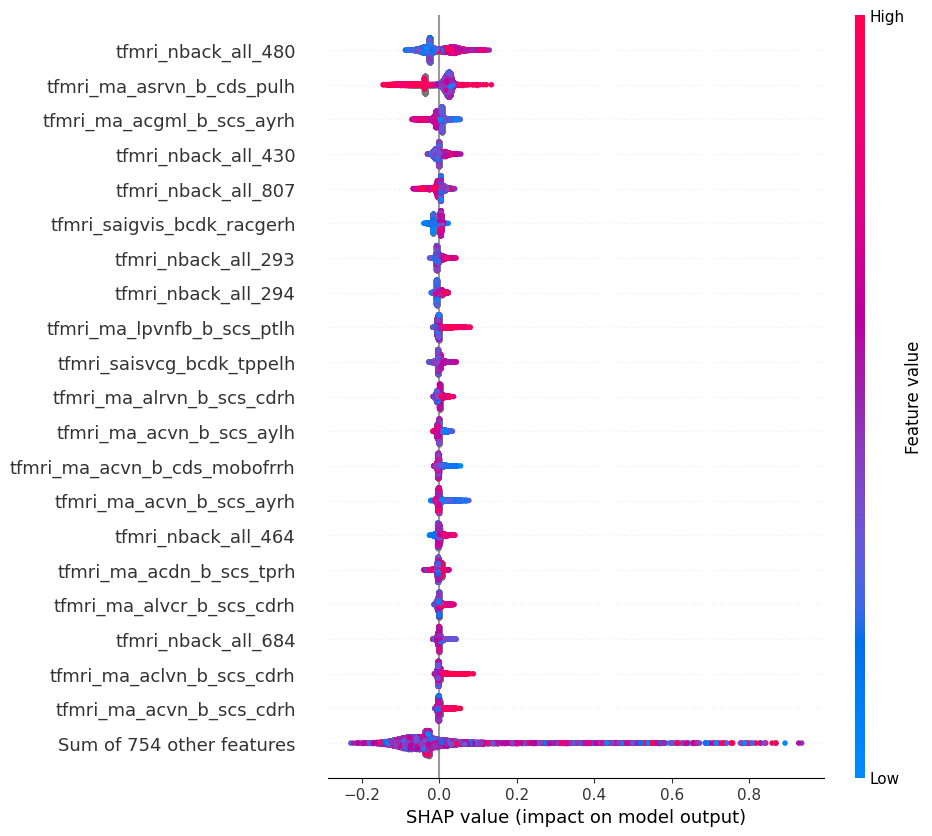

In [15]:
shap.plots.beeswarm(shap_values, max_display=21)

# SHAP dependence plots

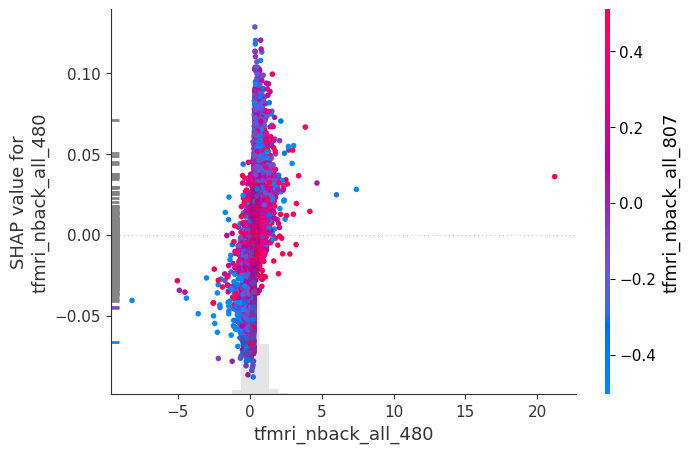

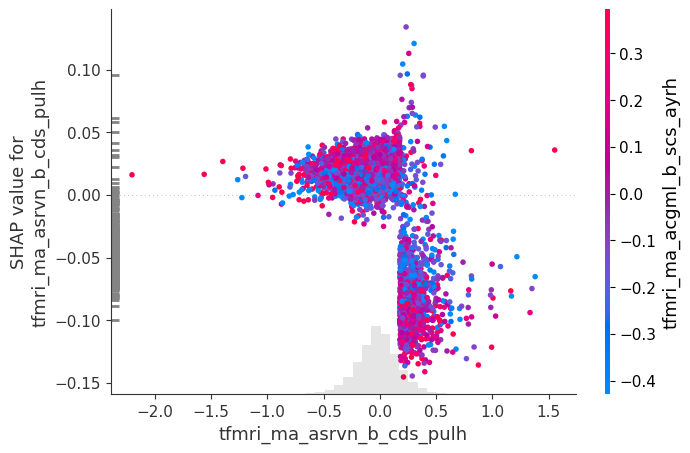

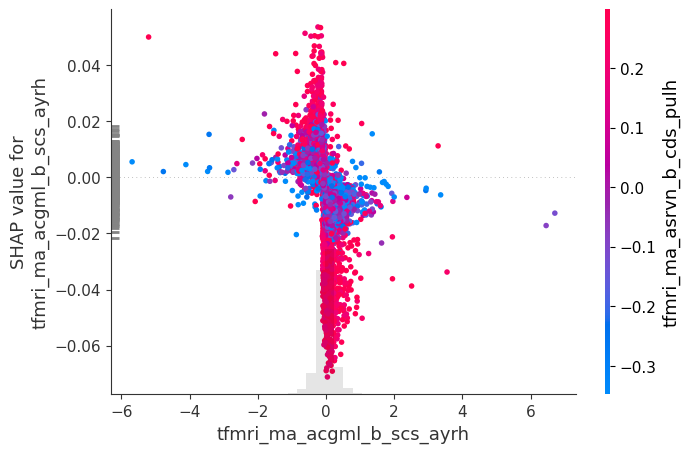

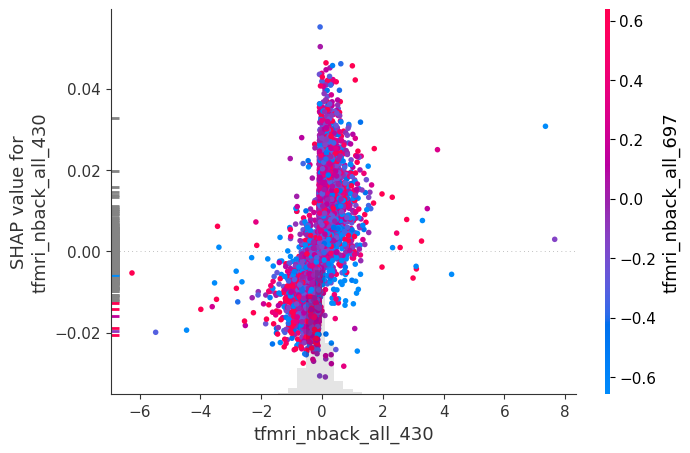

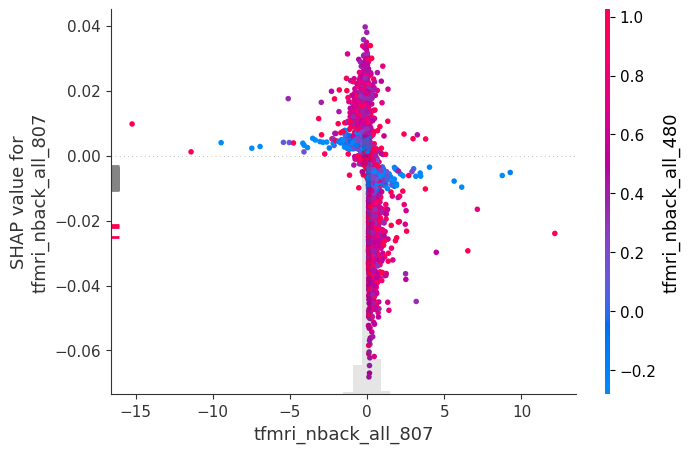

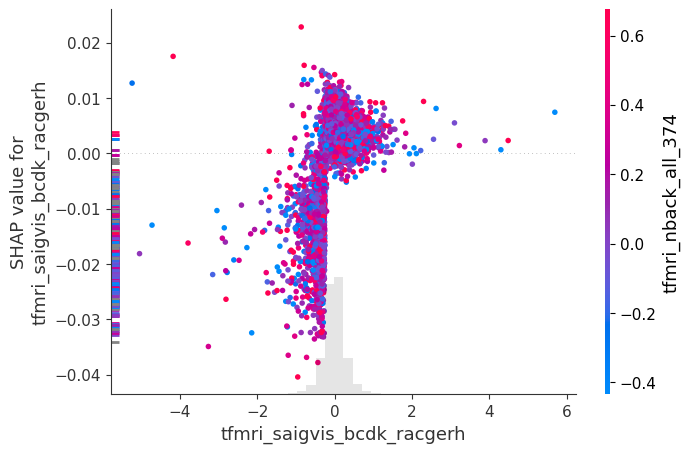

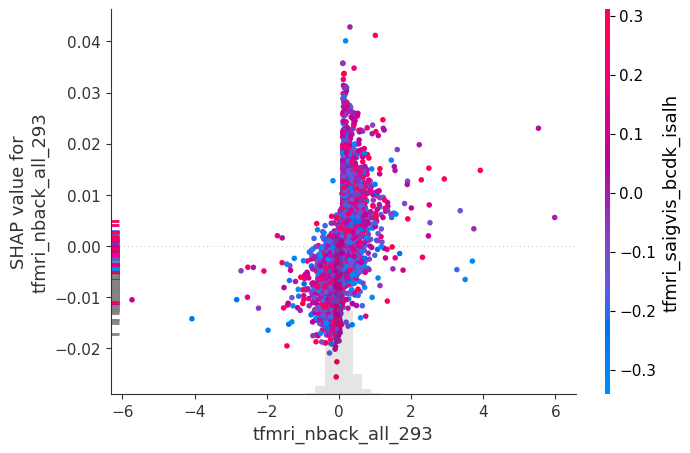

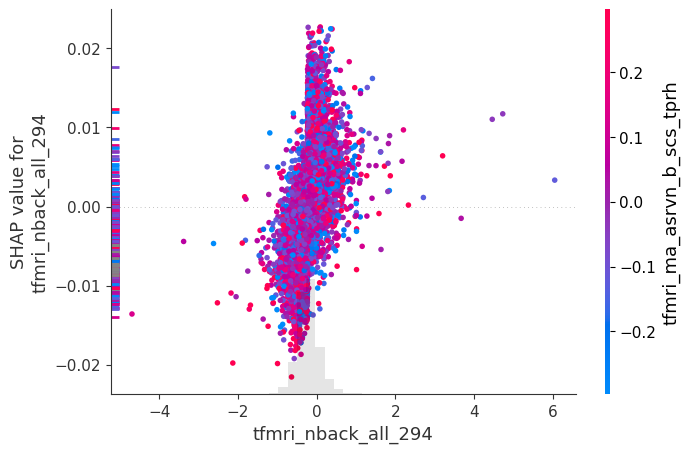

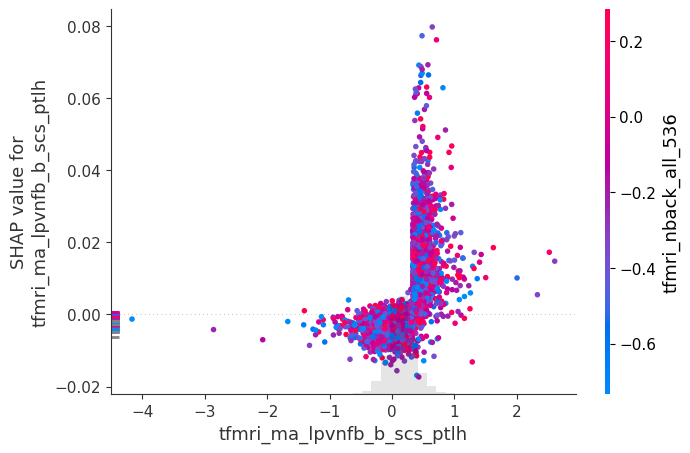

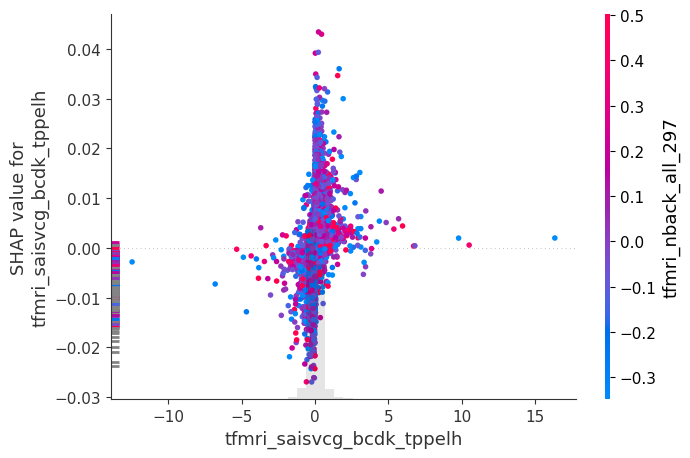

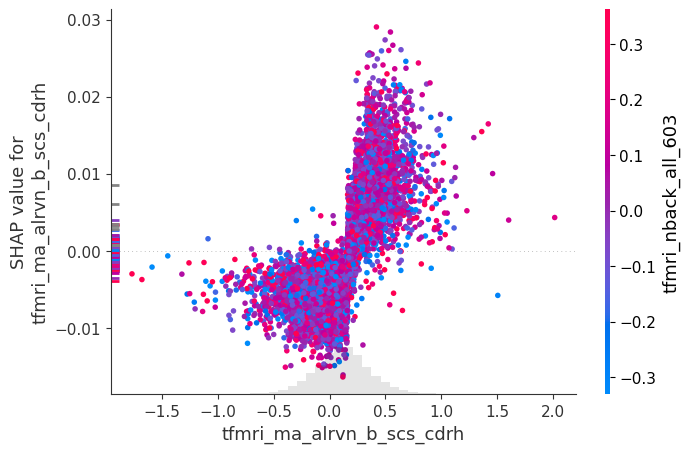

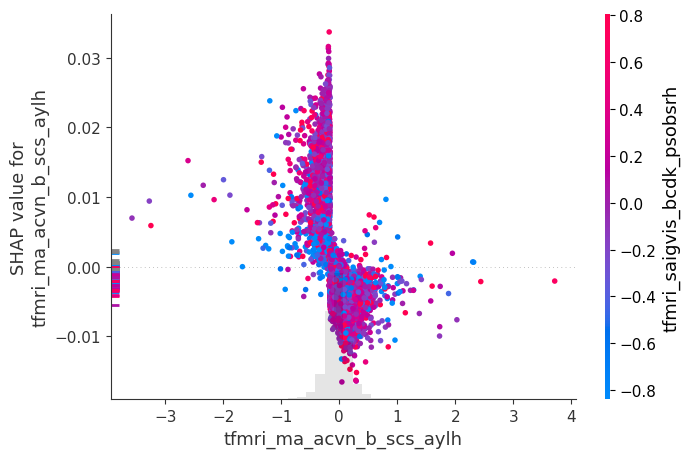

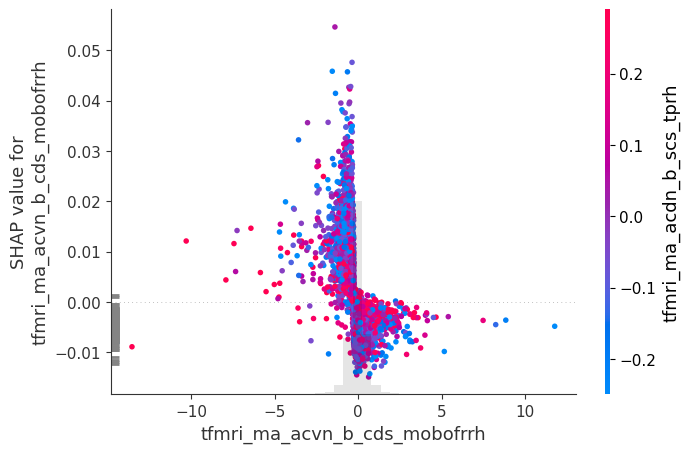

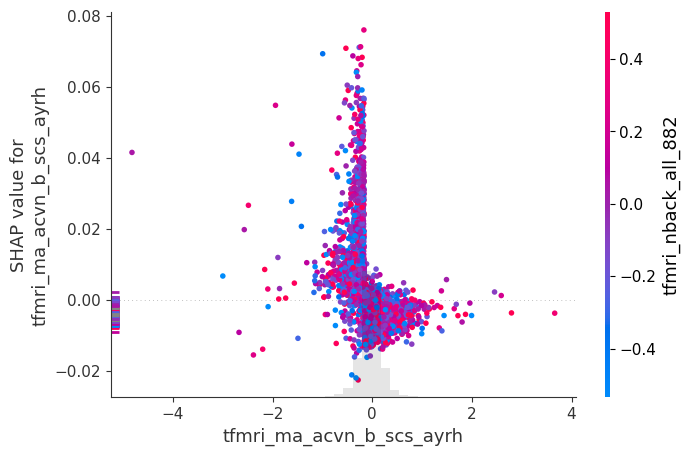

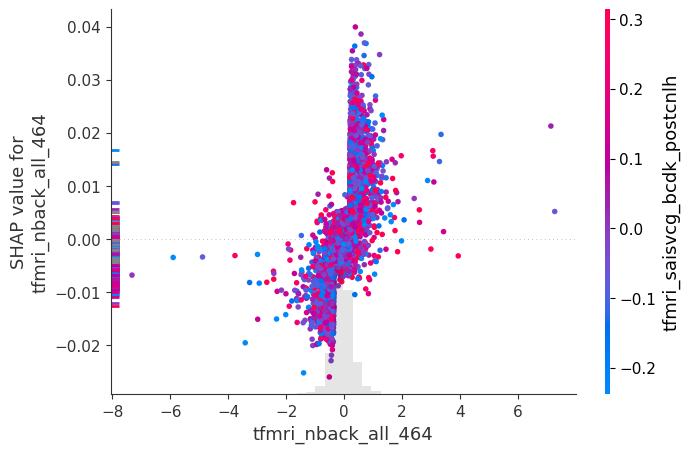

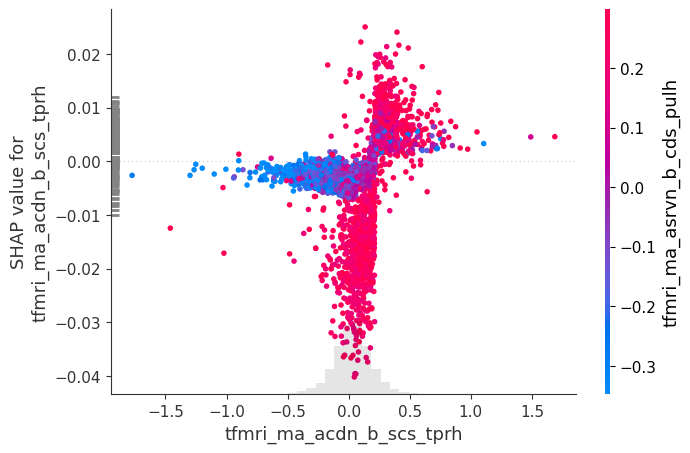

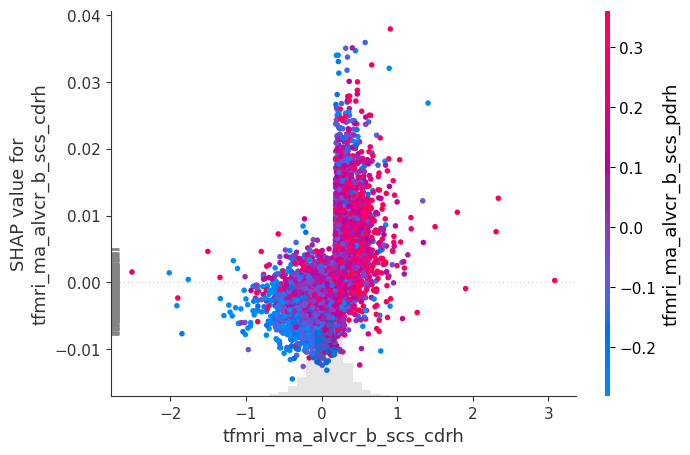

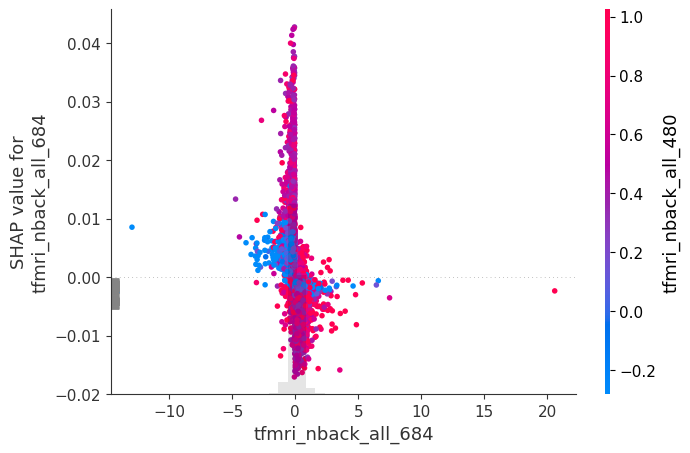

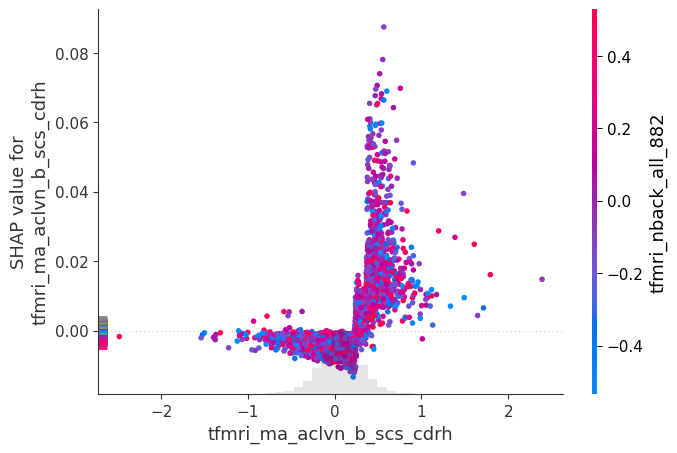

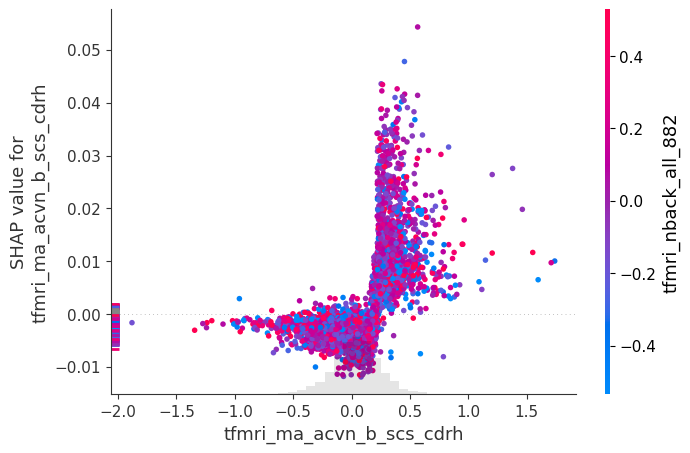

In [16]:
top_inds = np.argsort(-np.sum(np.abs(shap_values.values), 0))
for i in range(20):
    shap.plots.scatter(shap_values[:, top_inds[i]], color=shap_values)